# Heterogeneous GNNs on the Causal Elliptic++ Graph

Three architectures (GCN, GAT, GraphSAGE) on a heterogeneous graph of wallets
and transactions, with four edge / feature ablations and two evaluation protocols.

## Causality contract — strict per-target at training, val, and test

For **every** prediction (training labels, val labels, test labels), the model
sees only graph state with `t ≤ k` where `k` is the target tx's own timestep.
**No future information ever reaches a prediction, even within the training
window.** Implementation:

- For each timestep `k`, `build_snapshot(k, ablation)` returns a graph with
  edges satisfying `edge_t ≤ k` and wallet features cumulative through `k`.
- Training iterates train timesteps in shuffled order. Per `k`, the model is
  forward-passed on a `NeighborLoader`-sampled subgraph of `snapshot(k)`, with
  loss computed only on training-label tx seeds at exactly `t = k`.
- Validation and test follow the same per-timestep sampled-forward pattern.

This matches **phase1**'s `np.searchsorted(side="left")` semantics
(strict `τ < t` priors per target) — but extended to message-passing GNN
training, where phase1 only needed it at feature precomputation time.

### Per-snapshot construction

- **`tx` node features**: from `txs_features.csv` (raw 182). For the
  `full+traj` ablation, **augmented with the 103 phase1 trajectory features**
  computed under strict per-target causality.
- **`wallet` node features**: causal cumulative through `k` from
  `wallets_features_causal.csv`. Never includes activity from `t > k`.
- **bipartite addr↔tx edges**: included iff host tx `t_tx ≤ k`.
- **wallet↔wallet edges**: included iff `first_t(e) ≤ k`.
- **tx↔tx edges**: included iff `t_edge ≤ k`.
- **Both scalers fit on `t ≤ TRAIN_END = 29` only.**

## Architectures

- **GCN**: per-relation `GraphConv(aggr='mean')`
- **GAT**: per-relation `GATConv(heads=4, concat=False)` — multi-head attention
- **GraphSAGE**: per-relation `SAGEConv(aggr='max', normalize=True)` — max-pool + L2

## Ablations

1. **bipartite** = wallet↔tx only, raw tx features (182)
2. **+ wallet-wallet** = bipartite + AddrAddr causal, raw tx features (182)
3. **full** = bipartite + AddrAddr causal + tx↔tx, raw tx features (182)
4. **full+traj** = full graph + tx node features = raw + 103 phase1 trajectory
   features (285 dim) — combines message-passing with strong per-target causal
   signal (label propagation, second-hop illicit exposure, recency-to-illicit,
   etc.).

## Stability mitigations for strict training (cell 1)

Per-timestep updates are noisier than full-batch — a tx at `t=10` and a tx at
`t=29` get different graph snapshots, giving per-step gradient variance
across the training window. To keep training stable while preserving the
strict contract:

- `LR = 5e-4` (down from 1e-3) — smaller noisy steps
- `GRAD_CLIP = 1.0` — prevent occasional update blowup
- `PATIENCE = 12` (up from 10) — more lenient early-stopping on a noisier val curve
- `DROPOUT = 0.4`, `WEIGHT_DECAY = 5e-4` — regularise against overfit on 26K labels
- `GAT_HEADS = 4` (down from 8) — smaller attention head count
- bf16 autocast (stable; no GradScaler since bf16 has fp32 dynamic range)
- Per-epoch shuffling of the timestep-iteration order so Adam doesn't see the
  same temporal sequence each pass

In [1]:
!pip install -q \
  "numpy<2" \
  "torch-geometric>=2.4.0" \
  "scikit-learn>=1.3.0" \
  "pandas>=2.0.0" \
  "matplotlib>=3.7.0" \
  "seaborn>=0.12.0" \
  "pyyaml>=6.0" \
  "tqdm>=4.65.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

In [ ]:
!pip install -q --force-reinstall \
  "numpy<2" \
  "pandas>=2.0,<2.2.3" \
  "scikit-learn>=1.3.0" \
  "torch-geometric>=2.4.0"

import os
os.kill(os.getpid(), 9)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 145.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
TORCH = ".".join(torch.__version__.split("+")[0].split(".")[:2]) + ".0"   # e.g. '2.5.0'
CUDA  = f"cu{torch.version.cuda.replace('.', '')}" if torch.version.cuda else "cpu"
print(f"installing pyg extensions for torch={TORCH} cuda={CUDA}")
!pip install -q pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

import os
os.kill(os.getpid(), 9)

installing pyg extensions for torch=2.10.0 cuda=cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 53.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 52.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 133.2 MB/s eta 0:00:00


In [8]:
# Cell 1: imports, paths, config

import os, sys, time, json, math, copy, gc
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, precision_recall_curve
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GraphConv, GATConv, SAGEConv
from torch_geometric.loader import NeighborLoader

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

REPO = "/content/drive/MyDrive/stat175-final-project"

ACTORS = os.path.join(REPO, "actor_data")
TX = os.path.join(REPO, "data")
print("repo:", REPO)

# Reproducibility
RANDOM_SEED = 175
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# Time-window protocol
N_TIMESTEPS = 49
TRAIN_END = 29
VAL_END = 34
TEST_START = 35
TEST_TIMESTEPS = list(range(TEST_START, N_TIMESTEPS + 1))
WALK_VAL_WIN = 4

# Model + training config (A100-targeted; tuned for ~26K train labels with up to
# 285 tx features, hetero graph w/ ~5M edges, STRICT per-target training)
HIDDEN = 128
N_LAYERS = 3
DROPOUT = 0.4
GAT_HEADS = 4
LR = 5e-4                  # lowered from 1e-3 -- per-target training has noisier per-step gradients
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0            # clip per-step gradient norm; combats noise blowup in per-timestep updates
N_EPOCHS_STRICT = 50
N_EPOCHS_WALK = 10         # lowered from 15 -- per-target walk-forward is ~3x heavier per step
PATIENCE = 12              # raised from 10 -- noisier val curve under strict training

# NeighborLoader sampling config -- avoids OOM on the ~1M-node hetero graph.
SAMPLE_FANOUT = [20, 15, 15]
SAMPLE_BATCH  = 2048

# bf16 mixed-precision: ~50% activation memory + ~2x throughput on A100 Tensor Cores.
USE_BF16 = True

# Device: CUDA on A100, fall back
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("device:", DEVICE, " bf16:", USE_BF16 and DEVICE.type == "cuda")


def free_cuda():
    """Release CUDA cache + Python references between models."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def amp_ctx():
    """bf16 autocast on CUDA when enabled; no-op otherwise."""
    if USE_BF16 and DEVICE.type == "cuda":
        return torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16)
    return nullcontext()


Mounted at /content/drive
repo: /content/drive/MyDrive/stat175-final-project
device: cuda  bf16: True


In [2]:
# Cell 2: load all data

t0 = time.time()

tx_feat_df = pd.read_csv(os.path.join(TX, "txs_features.csv"))
tx_id_arr = tx_feat_df["txId"].values
tx_t_arr  = tx_feat_df["Time step"].values.astype(np.int64)
TX_FEAT_COLS = [c for c in tx_feat_df.columns if c not in ("txId", "Time step")]
tx_X_raw = tx_feat_df[TX_FEAT_COLS].fillna(0.0).values.astype(np.float32)
N_TX = len(tx_id_arr)
F_TX = tx_X_raw.shape[1]
print(f"tx: N={N_TX:,}  F_TX={F_TX}  t-range=[{tx_t_arr.min()}, {tx_t_arr.max()}]")

tx_cls_df = pd.read_csv(os.path.join(TX, "txs_classes.csv"))
cls_map = dict(zip(tx_cls_df["txId"].values, tx_cls_df["class"].values.astype(np.int64)))
tx_label = np.full(N_TX, -1, dtype=np.int64)
for i, txid in enumerate(tx_id_arr):
    c = cls_map.get(txid)
    if c == 1:   tx_label[i] = 1
    elif c == 2: tx_label[i] = 0
print(f"tx labels: illicit={(tx_label==1).sum():,}  licit={(tx_label==0).sum():,}  unknown={(tx_label==-1).sum():,}")

wf = pd.read_csv(os.path.join(ACTORS, "wallets_features_causal.csv"))
WF_FEAT_COLS = [c for c in wf.columns if c not in ("address", "Time step")]
F_W = len(WF_FEAT_COLS)
print(f"wallet causal feats: {len(wf):,} rows, F_W={F_W}")

ai = pd.read_csv(os.path.join(ACTORS, "AddrTx_edgelist.txt"))
ao = pd.read_csv(os.path.join(ACTORS, "TxAddr_edgelist.txt"))
print(f"bipartite: in={len(ai):,}  out={len(ao):,}")

aa = pd.read_csv(os.path.join(ACTORS, "AddrAddr_edgelist_causal.csv"))
print(f"wallet-wallet edges: {len(aa):,}  first_t range=[{int(aa['first_t'].min())}, {int(aa['first_t'].max())}]")

tt = pd.read_csv(os.path.join(TX, "txs_edgelist.csv"))
print(f"tx-tx edges: {len(tt):,}")

print(f"[load] {time.time()-t0:.1f}s")


tx: N=203,769  F_TX=182  t-range=[1, 49]
tx labels: illicit=4,545  licit=42,019  unknown=157,205
wallet causal feats: 1,268,260 rows, F_W=55
bipartite: in=477,117  out=837,124
wallet-wallet edges: 2,868,964  first_t range=[1, 49]
tx-tx edges: 234,355
[load] 51.6s


In [3]:
# Cell 3: node ID maps + per-edge timestamp arrays

t0 = time.time()

tx_to_idx = {txid: i for i, txid in enumerate(tx_id_arr)}
wallet_addrs = wf["address"].drop_duplicates().values
N_W = len(wallet_addrs)
w_to_idx = {a: i for i, a in enumerate(wallet_addrs)}
print(f"N_TX={N_TX:,}  N_W={N_W:,}")

ai_w = np.array([w_to_idx[w] for w in ai["input_address"].values], dtype=np.int64)
ai_x = np.array([tx_to_idx[t] for t in ai["txId"].values], dtype=np.int64)
ai_t = tx_t_arr[ai_x]

ao_x = np.array([tx_to_idx[t] for t in ao["txId"].values], dtype=np.int64)
ao_w = np.array([w_to_idx[w] for w in ao["output_address"].values], dtype=np.int64)
ao_t = tx_t_arr[ao_x]

aa_in  = np.array([w_to_idx[w] for w in aa["input_address"].values],  dtype=np.int64)
aa_out = np.array([w_to_idx[w] for w in aa["output_address"].values], dtype=np.int64)
aa_t   = aa["first_t"].values.astype(np.int64)

tt_a = np.array([tx_to_idx[t] for t in tt["txId1"].values], dtype=np.int64)
tt_b = np.array([tx_to_idx[t] for t in tt["txId2"].values], dtype=np.int64)
tt_t = tx_t_arr[tt_a]
assert (tx_t_arr[tt_a] == tx_t_arr[tt_b]).all(), "tx-tx edges should be within-timestep"

print(f"  bipartite: in={len(ai_w):,}  out={len(ao_x):,}  walletXwallet={len(aa_in):,}  txXtx={len(tt_a):,}")
print(f"[node/edge build] {time.time()-t0:.1f}s")


N_TX=203,769  N_W=822,942
  bipartite: in=477,117  out=837,124  walletXwallet=2,868,964  txXtx=234,355
[node/edge build] 2.8s


In [4]:
# Cell 4: wallet feature lookup table

t0 = time.time()

wf_sorted = wf.sort_values(["address", "Time step"]).reset_index(drop=True)
addr_arr = wf_sorted["address"].values
t_arr_wf = wf_sorted["Time step"].values.astype(np.int64)
WF_RAW = wf_sorted[WF_FEAT_COLS].fillna(0.0).values.astype(np.float32)

last_row_at_T = np.full((N_TIMESTEPS + 1, N_W), -1, dtype=np.int32)
addr_to_id = np.array([w_to_idx[a] for a in wf_sorted["address"].values], dtype=np.int64)
for j in range(len(wf_sorted)):
    last_row_at_T[t_arr_wf[j], addr_to_id[j]] = j
for T in range(1, N_TIMESTEPS + 1):
    mask = (last_row_at_T[T] == -1)
    last_row_at_T[T, mask] = last_row_at_T[T - 1, mask]
print(f"  last_row_at_T: shape={last_row_at_T.shape} ({last_row_at_T.nbytes/1024/1024:.0f} MB)")


def wallet_features_at_T(T_query: int) -> np.ndarray:
    """(N_W, F_W); row w = causal features at latest t' <= T_query (zeros if none)."""
    idx = last_row_at_T[T_query]
    out = np.zeros((N_W, F_W), dtype=np.float32)
    mask = idx >= 0
    out[mask] = WF_RAW[idx[mask]]
    return out

print(f"[wallet feature lookup] {time.time()-t0:.1f}s")


  last_row_at_T: shape=(50, 822942) (157 MB)
[wallet feature lookup] 6.0s


In [5]:
# Cell 4b: causal wallet-trajectory features (port from phase1_trajectory_signal.ipynb)
#
# 103 features per tx, computed using STRICT tau < t priors via
# np.searchsorted(side="left"). For each target tx T at time t, every feature
# uses only events with t' < t -- the same per-target causality contract phase1
# enforces. Used as augmented tx node features in the "full+traj" ablation.

t0 = time.time()
print("Building chronological structures for trajectory features...")

# Per-tx incident wallet lists (mirrors phase1's incident_in / incident_out)
incident_in  = defaultdict(list)
incident_out = defaultdict(list)
for w_idx, tx_idx in zip(ai_w, ai_x):
    incident_in[int(tx_idx)].append(int(w_idx))
for tx_idx, w_idx in zip(ao_x, ao_w):
    incident_out[int(tx_idx)].append(int(w_idx))

# Per-wallet sorted (t, tx, label) timeline. A wallet can be both input and
# output of the same tx; dedup (w, tx).
seen = set()
pairs = []
for w_idx, tx_idx in zip(ai_w, ai_x):
    key = (int(w_idx), int(tx_idx))
    if key in seen: continue
    seen.add(key)
    pairs.append((int(w_idx), int(tx_idx), int(tx_t_arr[tx_idx]), int(tx_label[tx_idx])))
for tx_idx, w_idx in zip(ao_x, ao_w):
    key = (int(w_idx), int(tx_idx))
    if key in seen: continue
    seen.add(key)
    pairs.append((int(w_idx), int(tx_idx), int(tx_t_arr[tx_idx]), int(tx_label[tx_idx])))
del seen
pairs.sort(key=lambda r: (r[0], r[2]))

wallet_t_traj   = {}
wallet_tx_traj  = {}
wallet_lab_traj = {}
prev_w = -1
buf_t, buf_tx, buf_lab = [], [], []
for w, tx, t, lab in pairs:
    if w != prev_w:
        if prev_w >= 0:
            wallet_t_traj[prev_w]   = np.array(buf_t,   dtype=np.int64)
            wallet_tx_traj[prev_w]  = np.array(buf_tx,  dtype=np.int64)
            wallet_lab_traj[prev_w] = np.array(buf_lab, dtype=np.int64)
        prev_w = w
        buf_t, buf_tx, buf_lab = [], [], []
    buf_t.append(t); buf_tx.append(tx); buf_lab.append(lab)
if prev_w >= 0:
    wallet_t_traj[prev_w]   = np.array(buf_t,   dtype=np.int64)
    wallet_tx_traj[prev_w]  = np.array(buf_tx,  dtype=np.int64)
    wallet_lab_traj[prev_w] = np.array(buf_lab, dtype=np.int64)
del pairs

wallet_event_count = {w: len(arr) for w, arr in wallet_t_traj.items()}

# Per-wallet first-illicit time (for second-hop exposure feature)
wallet_has_illicit_by = {}
for w, labs in wallet_lab_traj.items():
    illicit_mask = (labs == 1)
    if illicit_mask.any():
        wallet_has_illicit_by[w] = int(wallet_t_traj[w][illicit_mask].min())

print(f"  wallets with timelines: {len(wallet_t_traj):,}  illicit history: {len(wallet_has_illicit_by):,}")
print(f"[trajectory chronological structures] {time.time()-t0:.1f}s")

# === Trajectory feature engineering (faithful port of phase1) =================
print("\nComputing trajectory features for all transactions...")
tic = time.time()

agg_feat_names = ["total_BTC", "fees", "num_input_addresses", "num_output_addresses"]
agg_feat_idxs  = [TX_FEAT_COLS.index(c) for c in agg_feat_names]
total_btc_idx  = TX_FEAT_COLS.index("total_BTC")
F_AGG = len(agg_feat_names)

MAX_INCIDENT_PER_SIDE = 32
MAX_CO_WALLETS        = 150
RECENCY_SENTINEL      = N_TIMESTEPS * 2
DECAY_RATE            = 0.2


def pick_top_wallets(wlist, k=MAX_INCIDENT_PER_SIDE):
    if len(wlist) <= k: return list(wlist)
    cnts = np.array([wallet_event_count.get(w, 0) for w in wlist], dtype=np.int64)
    order = np.argsort(-cnts, kind="stable")
    return [wlist[i] for i in order[:k]]


def per_wallet_priors(w, t_query):
    tarr = wallet_t_traj.get(w)
    if tarr is None: return None
    cut = int(np.searchsorted(tarr, t_query, side="left"))   # STRICT tau < t_query
    if cut == 0: return None
    prior_t   = tarr[:cut]
    prior_lab = wallet_lab_traj[w][:cut]
    prior_tx  = wallet_tx_traj[w][:cut]

    illicit_mask = (prior_lab == 1)
    licit_mask   = (prior_lab == 0)
    n_illicit    = int(illicit_mask.sum())
    n_licit      = int(licit_mask.sum())
    n_labelled   = n_illicit + n_licit
    last_illicit_t = int(prior_t[illicit_mask].max()) if n_illicit > 0 else -1
    if n_illicit > 0:
        decay_w = np.exp(-DECAY_RATE * (t_query - prior_t[illicit_mask]).astype(np.float64))
        decayed_illicit_score = float(decay_w.sum())
    else:
        decayed_illicit_score = 0.0
    illicit_frac = n_illicit / max(n_labelled, 1)

    co_wallets = set()
    for tx_i in prior_tx:
        tx_i_int = int(tx_i)
        for cw in incident_in.get(tx_i_int, []):
            if cw != w: co_wallets.add(cw)
        for cw in incident_out.get(tx_i_int, []):
            if cw != w: co_wallets.add(cw)
        if len(co_wallets) >= MAX_CO_WALLETS: break
    n_co_wallets = len(co_wallets)
    n_co_illicit = sum(1 for cw in co_wallets
                      if wallet_has_illicit_by.get(cw) is not None
                      and wallet_has_illicit_by[cw] < t_query)

    unique_in_partners, unique_out_partners = set(), set()
    for tx_i in prior_tx:
        tx_i_int = int(tx_i)
        for cw in incident_in.get(tx_i_int, []):
            if cw != w: unique_in_partners.add(cw)
        for cw in incident_out.get(tx_i_int, []):
            if cw != w: unique_out_partners.add(cw)
    n_in_partners  = len(unique_in_partners)
    n_out_partners = len(unique_out_partners)
    fan_asymmetry  = n_out_partners / max(n_in_partners, 1)

    n_prior = int(cut)
    age     = int(t_query - prior_t[0])
    recency = int(t_query - prior_t[-1])
    n_recent_5 = int(((t_query - prior_t) <= 5).sum())
    n_recent_1 = int(((t_query - prior_t) <= 1).sum())
    if n_prior >= 2:
        iat = np.diff(prior_t.astype(np.float64))
        iat_mean = float(iat.mean()); iat_std = float(iat.std())
        burstiness = float((iat_std - iat_mean) / (iat_std + iat_mean + 1e-8))
    else:
        iat_mean = iat_std = 0.0; burstiness = 0.0
    velocity = n_recent_5 / max(n_prior, 1)

    feat_vals = tx_X_raw[prior_tx][:, agg_feat_idxs]   # [k, F_AGG]
    return {
        "n": n_prior, "n_illicit": n_illicit, "n_licit": n_licit,
        "illicit_frac": illicit_frac,
        "last_illicit_t": last_illicit_t, "decayed_illicit": decayed_illicit_score,
        "n_co_wallets": n_co_wallets, "n_co_illicit": n_co_illicit,
        "co_illicit_frac": n_co_illicit / max(n_co_wallets, 1),
        "n_in_partners": n_in_partners, "n_out_partners": n_out_partners,
        "fan_asymmetry": fan_asymmetry,
        "first_seen_t": int(prior_t[0]), "last_seen_t": int(prior_t[-1]),
        "age": age, "recency": recency,
        "n_recent_5": n_recent_5, "n_recent_1": n_recent_1,
        "iat_mean": iat_mean, "iat_std": iat_std, "burstiness": burstiness,
        "velocity": velocity,
        "feat_means": feat_vals.mean(axis=0), "feat_maxes": feat_vals.max(axis=0),
    }


def aggregate_side(summaries, side, t_T):
    n_total = len(summaries)
    valid = [s for s in summaries if s is not None]
    n_w_prior = len(valid)
    p = side
    out = {
        f"{p}_n_wallets":            n_total,
        f"{p}_n_wallets_with_prior": n_w_prior,
        f"{p}_frac_first_appearance": (n_total - n_w_prior) / max(n_total, 1),
    }
    if not valid:
        out.update({
            f"{p}_n_priors_sum": 0, f"{p}_n_priors_max": 0,
            f"{p}_n_illicit_sum": 0, f"{p}_n_illicit_max": 0, f"{p}_n_licit_sum": 0,
            f"{p}_n_wallets_with_illicit": 0,
            f"{p}_n_wallets_illicit_frac_gt0": 0, f"{p}_n_wallets_illicit_frac_gt50": 0,
            f"{p}_illicit_frac_max": 0.0, f"{p}_illicit_frac_mean": 0.0,
            f"{p}_decayed_illicit_max": 0.0, f"{p}_decayed_illicit_sum": 0.0,
            f"{p}_recency_to_illicit_min": RECENCY_SENTINEL,
            f"{p}_co_illicit_sum": 0, f"{p}_co_illicit_max": 0,
            f"{p}_co_illicit_frac_max": 0.0, f"{p}_co_illicit_frac_mean": 0.0,
            f"{p}_n_co_wallets_sum": 0,
            f"{p}_fan_asymmetry_max": 0.0, f"{p}_fan_asymmetry_mean": 0.0,
            f"{p}_n_in_partners_max": 0, f"{p}_n_out_partners_max": 0,
            f"{p}_frac_single_use": 0.0,
            f"{p}_age_max": 0, f"{p}_age_mean": 0.0,
            f"{p}_recency_min": RECENCY_SENTINEL,
            f"{p}_n_recent_5_sum": 0, f"{p}_n_recent_5_max": 0,
            f"{p}_n_recent_1_sum": 0,
            f"{p}_velocity_max": 0.0, f"{p}_velocity_mean": 0.0,
            f"{p}_burstiness_max": 0.0, f"{p}_burstiness_mean": 0.0,
            f"{p}_iat_mean_min": 0.0, f"{p}_iat_std_max": 0.0,
        })
        for nm in agg_feat_names:
            out[f"{p}_prior_{nm}_mean_max"] = 0.0
            out[f"{p}_prior_{nm}_max_max"]  = 0.0
        return out

    ns      = np.array([s["n"]              for s in valid], dtype=np.float64)
    nis     = np.array([s["n_illicit"]      for s in valid], dtype=np.float64)
    nls     = np.array([s["n_licit"]        for s in valid], dtype=np.float64)
    ill_frac= np.array([s["illicit_frac"]   for s in valid], dtype=np.float64)
    dec_ill = np.array([s["decayed_illicit"]for s in valid], dtype=np.float64)
    last_ill= np.array([s["last_illicit_t"] for s in valid], dtype=np.int64)
    has_ill = (last_ill >= 0)
    rec_ill = np.where(has_ill, t_T - last_ill, RECENCY_SENTINEL).astype(np.float64)
    co_ill  = np.array([s["n_co_illicit"]    for s in valid], dtype=np.float64)
    co_n    = np.array([s["n_co_wallets"]    for s in valid], dtype=np.float64)
    co_frac = np.array([s["co_illicit_frac"] for s in valid], dtype=np.float64)
    fan_a   = np.array([s["fan_asymmetry"]   for s in valid], dtype=np.float64)
    n_inp   = np.array([s["n_in_partners"]   for s in valid], dtype=np.float64)
    n_outp  = np.array([s["n_out_partners"]  for s in valid], dtype=np.float64)
    ages    = np.array([s["age"]       for s in valid], dtype=np.float64)
    recs    = np.array([s["recency"]   for s in valid], dtype=np.float64)
    nr5     = np.array([s["n_recent_5"]for s in valid], dtype=np.float64)
    nr1     = np.array([s["n_recent_1"]for s in valid], dtype=np.float64)
    vel     = np.array([s["velocity"]  for s in valid], dtype=np.float64)
    burst   = np.array([s["burstiness"]for s in valid], dtype=np.float64)
    iat_m   = np.array([s["iat_mean"]  for s in valid], dtype=np.float64)
    iat_s   = np.array([s["iat_std"]   for s in valid], dtype=np.float64)
    feat_means = np.stack([s["feat_means"] for s in valid], axis=0)
    feat_maxes = np.stack([s["feat_maxes"] for s in valid], axis=0)

    out.update({
        f"{p}_n_priors_sum": int(ns.sum()),  f"{p}_n_priors_max": int(ns.max()),
        f"{p}_n_illicit_sum": int(nis.sum()), f"{p}_n_illicit_max": int(nis.max()),
        f"{p}_n_licit_sum":   int(nls.sum()),
        f"{p}_n_wallets_with_illicit":      int(has_ill.sum()),
        f"{p}_n_wallets_illicit_frac_gt0":  int((ill_frac > 0.0).sum()),
        f"{p}_n_wallets_illicit_frac_gt50": int((ill_frac > 0.5).sum()),
        f"{p}_illicit_frac_max":   float(ill_frac.max()),
        f"{p}_illicit_frac_mean":  float(ill_frac.mean()),
        f"{p}_decayed_illicit_max":float(dec_ill.max()),
        f"{p}_decayed_illicit_sum":float(dec_ill.sum()),
        f"{p}_recency_to_illicit_min": float(rec_ill.min()),
        f"{p}_co_illicit_sum": int(co_ill.sum()), f"{p}_co_illicit_max": int(co_ill.max()),
        f"{p}_co_illicit_frac_max":  float(co_frac.max()),
        f"{p}_co_illicit_frac_mean": float(co_frac.mean()),
        f"{p}_n_co_wallets_sum":     int(co_n.sum()),
        f"{p}_fan_asymmetry_max":    float(fan_a.max()),
        f"{p}_fan_asymmetry_mean":   float(fan_a.mean()),
        f"{p}_n_in_partners_max":    int(n_inp.max()),
        f"{p}_n_out_partners_max":   int(n_outp.max()),
        f"{p}_frac_single_use":      sum(1 for s in valid if s["n"] == 1) / max(n_w_prior, 1),
        f"{p}_age_max":   int(ages.max()),  f"{p}_age_mean": float(ages.mean()),
        f"{p}_recency_min": int(recs.min()),
        f"{p}_n_recent_5_sum": int(nr5.sum()), f"{p}_n_recent_5_max": int(nr5.max()),
        f"{p}_n_recent_1_sum": int(nr1.sum()),
        f"{p}_velocity_max":  float(vel.max()),    f"{p}_velocity_mean":  float(vel.mean()),
        f"{p}_burstiness_max":float(burst.max()),  f"{p}_burstiness_mean":float(burst.mean()),
        f"{p}_iat_mean_min":  float(iat_m.min()),  f"{p}_iat_std_max":    float(iat_s.max()),
    })
    for k_, nm in enumerate(agg_feat_names):
        out[f"{p}_prior_{nm}_mean_max"] = float(feat_means[:, k_].max())
        out[f"{p}_prior_{nm}_max_max"]  = float(feat_maxes[:, k_].max())
    return out


rows = []
PROGRESS = 25_000
for tx_idx in range(N_TX):
    t_T = int(tx_t_arr[tx_idx])
    T_total_btc = float(tx_X_raw[tx_idx, total_btc_idx])
    in_w  = pick_top_wallets(incident_in.get(tx_idx, []))
    out_w = pick_top_wallets(incident_out.get(tx_idx, []))
    in_summ  = [per_wallet_priors(w, t_T) for w in in_w]
    out_summ = [per_wallet_priors(w, t_T) for w in out_w]
    row = {}
    row.update(aggregate_side(in_summ,  "in",  t_T))
    row.update(aggregate_side(out_summ, "out", t_T))
    # Group 5: cross-side composites
    row["both_sides_have_illicit"]      = int(row["in_n_wallets_with_illicit"] > 0 and row["out_n_wallets_with_illicit"] > 0)
    row["total_n_illicit_priors"]       = row["in_n_illicit_sum"] + row["out_n_illicit_sum"]
    row["total_n_wallets_with_illicit"] = row["in_n_wallets_with_illicit"] + row["out_n_wallets_with_illicit"]
    row["total_co_illicit"]             = row["in_co_illicit_sum"] + row["out_co_illicit_sum"]
    row["min_recency_to_illicit"]       = min(row["in_recency_to_illicit_min"], row["out_recency_to_illicit_min"])
    row["max_illicit_frac_either_side"] = max(row["in_illicit_frac_max"], row["out_illicit_frac_max"])
    row["max_decayed_illicit_either"]   = max(row["in_decayed_illicit_max"], row["out_decayed_illicit_max"])
    row["max_co_illicit_frac_either"]   = max(row["in_co_illicit_frac_max"], row["out_co_illicit_frac_max"])
    row["total_frac_first_appearance"]  = (
        (row["in_frac_first_appearance"]  * max(row["in_n_wallets"],  1) +
         row["out_frac_first_appearance"] * max(row["out_n_wallets"], 1))
        / max(row["in_n_wallets"] + row["out_n_wallets"], 1)
    )
    max_prior_btc  = max(row.get("in_prior_total_BTC_max_max", 0),  row.get("out_prior_total_BTC_max_max", 0))
    mean_prior_btc = max(row.get("in_prior_total_BTC_mean_max", 0), row.get("out_prior_total_BTC_mean_max", 0))
    row["T_btc_vs_max_prior"]  = T_total_btc / max(max_prior_btc, 1.0)
    row["T_btc_vs_mean_prior"] = T_total_btc / max(mean_prior_btc, 1.0)
    rows.append(row)
    if tx_idx > 0 and tx_idx % PROGRESS == 0:
        elapsed = time.time() - tic
        eta = (N_TX - tx_idx) * elapsed / tx_idx
        print(f"  tx {tx_idx:>7,}/{N_TX:,}  ({elapsed:.0f}s, ETA {eta:.0f}s)")

traj_df  = pd.DataFrame(rows)
traj_X   = traj_df.values.astype(np.float32)
TRAJ_COLS = list(traj_df.columns)
F_TRAJ   = traj_X.shape[1]
print(f"\n  Done: {F_TRAJ} trajectory features x {N_TX:,} txs  ({time.time()-tic:.1f}s)")
print(f"[trajectory features total] {time.time()-t0:.1f}s")


Building chronological structures for trajectory features...
  wallets with timelines: 822,942  illicit history: 14,266
[trajectory chronological structures] 10.6s

Computing trajectory features for all transactions...
  tx  25,000/203,769  (5s, ETA 36s)
  tx  50,000/203,769  (15s, ETA 45s)
  tx  75,000/203,769  (26s, ETA 45s)
  tx 100,000/203,769  (42s, ETA 44s)
  tx 125,000/203,769  (58s, ETA 36s)
  tx 150,000/203,769  (66s, ETA 24s)
  tx 175,000/203,769  (77s, ETA 13s)
  tx 200,000/203,769  (88s, ETA 2s)

  Done: 103 trajectory features x 203,769 txs  (96.1s)
[trajectory features total] 106.7s


In [6]:
# Cell 5: standardize features (fit on TRAIN_END window only)

t0 = time.time()

# Raw tx features (182): standardize on training rows
tx_train_mask = (tx_t_arr <= TRAIN_END)
tx_scaler = StandardScaler()
tx_scaler.fit(tx_X_raw[tx_train_mask])
TX_X = tx_scaler.transform(tx_X_raw).astype(np.float32)
print(f"tx_X std (raw {F_TX}): shape={TX_X.shape}  fit on {tx_train_mask.sum():,} train txs (t<={TRAIN_END})")

# Trajectory features (103): standardize on training rows; concat with raw -> augmented
traj_scaler = StandardScaler()
traj_scaler.fit(traj_X[tx_train_mask])
TRAJ_X_STD = traj_scaler.transform(traj_X).astype(np.float32)
TX_X_AUG = np.concatenate([TX_X, TRAJ_X_STD], axis=1).astype(np.float32)
F_TX_AUG = TX_X_AUG.shape[1]
print(f"tx_X_aug std (raw + traj = {F_TX_AUG}): shape={TX_X_AUG.shape}  (used by 'full+traj' ablation)")

# Wallet features
train_wf_mask = (t_arr_wf <= TRAIN_END)
wf_scaler = StandardScaler()
wf_scaler.fit(WF_RAW[train_wf_mask])
WF_RAW = wf_scaler.transform(WF_RAW).astype(np.float32)
print(f"wf std: fit on {train_wf_mask.sum():,} causal rows with t<={TRAIN_END}")

print(f"[standardize] {time.time()-t0:.1f}s")


tx_X std (raw 182): shape=(203769, 182)  fit on 120,804 train txs (t<=29)
tx_X_aug std (raw + traj = 285): shape=(203769, 285)  (used by 'full+traj' ablation)
wf std: fit on 755,034 causal rows with t<=29
[standardize] 2.0s


In [7]:
# Cell 6: heterogeneous graph snapshot builder
#
# Four ablations:
#   1. "bipartite"      -- wallet<->tx only
#   2. "+wallet_wallet" -- bipartite + AddrAddr-causal
#   3. "full"           -- bipartite + AddrAddr-causal + tx<->tx (within-step)
#   4. "full+traj"      -- same edges as "full", but tx node features are
#                          augmented with the 103 phase1 trajectory features
#                          (causal per-target). Lets the GNN combine
#                          message-passing with strong precomputed signal.

ABLATIONS = ["bipartite", "+wallet_wallet", "full", "full+traj"]

T_AI_W = torch.from_numpy(ai_w);  T_AI_X = torch.from_numpy(ai_x);  T_AI_T = torch.from_numpy(ai_t)
T_AO_X = torch.from_numpy(ao_x);  T_AO_W = torch.from_numpy(ao_w);  T_AO_T = torch.from_numpy(ao_t)
T_AA_I = torch.from_numpy(aa_in); T_AA_O = torch.from_numpy(aa_out); T_AA_T = torch.from_numpy(aa_t)
T_TT_A = torch.from_numpy(tt_a);  T_TT_B = torch.from_numpy(tt_b);  T_TT_T = torch.from_numpy(tt_t)
T_TX_X     = torch.from_numpy(TX_X)        # raw 182 features
T_TX_X_AUG = torch.from_numpy(TX_X_AUG)    # raw + traj = 285 features


def build_snapshot(k: int, ablation: str, device=None) -> HeteroData:
    data = HeteroData()
    tx_x = T_TX_X_AUG if ablation == "full+traj" else T_TX_X
    data["tx"].x = tx_x if device is None else tx_x.to(device, non_blocking=True)
    wf_T = torch.from_numpy(wallet_features_at_T(k))
    data["wallet"].x = wf_T if device is None else wf_T.to(device, non_blocking=True)

    use_aa = ablation in ("+wallet_wallet", "full", "full+traj")
    use_tt = ablation in ("full", "full+traj")

    m_in  = (T_AI_T <= k); m_out = (T_AO_T <= k)
    e_w_to_tx     = torch.stack([T_AI_W[m_in],  T_AI_X[m_in]],  dim=0)
    e_tx_to_w_rev = torch.stack([T_AI_X[m_in],  T_AI_W[m_in]],  dim=0)
    e_tx_to_w     = torch.stack([T_AO_X[m_out], T_AO_W[m_out]], dim=0)
    e_w_to_tx_rev = torch.stack([T_AO_W[m_out], T_AO_X[m_out]], dim=0)
    if device is not None:
        e_w_to_tx     = e_w_to_tx.to(device, non_blocking=True)
        e_tx_to_w_rev = e_tx_to_w_rev.to(device, non_blocking=True)
        e_tx_to_w     = e_tx_to_w.to(device, non_blocking=True)
        e_w_to_tx_rev = e_w_to_tx_rev.to(device, non_blocking=True)
    data["wallet", "sends_to", "tx"].edge_index = e_w_to_tx
    data["tx", "rev_sends_to", "wallet"].edge_index = e_tx_to_w_rev
    data["tx", "pays_to", "wallet"].edge_index = e_tx_to_w
    data["wallet", "rev_pays_to", "tx"].edge_index = e_w_to_tx_rev

    if use_aa:
        m_aa = (T_AA_T <= k)
        e_co  = torch.stack([T_AA_I[m_aa], T_AA_O[m_aa]], dim=0)
        e_rco = torch.stack([T_AA_O[m_aa], T_AA_I[m_aa]], dim=0)
        if device is not None:
            e_co  = e_co.to(device, non_blocking=True)
            e_rco = e_rco.to(device, non_blocking=True)
        data["wallet", "co_tx", "wallet"].edge_index = e_co
        data["wallet", "rev_co_tx", "wallet"].edge_index = e_rco

    if use_tt:
        m_tt = (T_TT_T <= k)
        e_chain  = torch.stack([T_TT_A[m_tt], T_TT_B[m_tt]], dim=0)
        e_rchain = torch.stack([T_TT_B[m_tt], T_TT_A[m_tt]], dim=0)
        if device is not None:
            e_chain  = e_chain.to(device, non_blocking=True)
            e_rchain = e_rchain.to(device, non_blocking=True)
        data["tx", "tx_chain", "tx"].edge_index = e_chain
        data["tx", "rev_tx_chain", "tx"].edge_index = e_rchain

    return data


def edge_summary(data: HeteroData) -> str:
    parts = []
    for et in data.edge_types:
        n = data[et].edge_index.size(1)
        if n:
            parts.append(f"{et[0][:1]}-{et[1][:8]}-{et[2][:1]}: {n:,}")
    return " | ".join(parts)


for k in [1, 10, TRAIN_END, VAL_END, N_TIMESTEPS]:
    g = build_snapshot(k, "full")
    print(f"snapshot at k={k} (full): {edge_summary(g)}")
g_aug = build_snapshot(TRAIN_END, "full+traj")
print(f"snapshot at k={TRAIN_END} (full+traj): tx.x={tuple(g_aug['tx'].x.shape)} (raw+traj)")


snapshot at k=1 (full): w-sends_to-t: 22,132 | t-rev_send-w: 22,132 | t-pays_to-w: 31,487 | w-rev_pays-t: 31,487 | w-co_tx-w: 81,604 | w-rev_co_t-w: 81,604 | t-tx_chain-t: 9,164 | t-rev_tx_c-t: 9,164
snapshot at k=10 (full): w-sends_to-t: 143,486 | t-rev_send-w: 143,486 | t-pays_to-w: 219,795 | w-rev_pays-t: 219,795 | w-co_tx-w: 719,796 | w-rev_co_t-w: 719,796 | t-tx_chain-t: 71,732 | t-rev_tx_c-t: 71,732
snapshot at k=29 (full): w-sends_to-t: 277,110 | t-rev_send-w: 277,110 | t-pays_to-w: 508,872 | w-rev_pays-t: 508,872 | w-co_tx-w: 1,521,888 | w-rev_co_t-w: 1,521,888 | t-tx_chain-t: 140,223 | t-rev_tx_c-t: 140,223
snapshot at k=34 (full): w-sends_to-t: 310,969 | t-rev_send-w: 310,969 | t-pays_to-w: 567,184 | w-rev_pays-t: 567,184 | w-co_tx-w: 1,817,225 | w-rev_co_t-w: 1,817,225 | t-tx_chain-t: 156,843 | t-rev_tx_c-t: 156,843
snapshot at k=49 (full): w-sends_to-t: 477,117 | t-rev_send-w: 477,117 | t-pays_to-w: 837,124 | w-rev_pays-t: 837,124 | w-co_tx-w: 2,868,964 | w-rev_co_t-w: 2,86

In [9]:
# Cell 7: heterogeneous GNN models (GCN / GAT / GraphSAGE)
#
# HeteroGNN takes f_tx as a constructor arg so the same class handles both raw
# (182-dim) and raw+traj (285-dim) tx features. Determined per ablation in
# train_inductive (next cell).

def make_conv(name: str, hidden: int, edge_types):
    if name == "gcn":
        return HeteroConv({et: GraphConv((-1, -1), hidden, aggr="mean", bias=True) for et in edge_types}, aggr="sum")
    if name == "gat":
        return HeteroConv({et: GATConv((-1, -1), hidden, heads=GAT_HEADS, concat=False, add_self_loops=False, dropout=DROPOUT) for et in edge_types}, aggr="sum")
    if name == "sage":
        return HeteroConv({et: SAGEConv((-1, -1), hidden, aggr="max", normalize=True) for et in edge_types}, aggr="sum")
    raise ValueError(name)


class HeteroGNN(nn.Module):
    def __init__(self, conv_name: str, edge_types, f_tx: int = F_TX, hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.tx_in = nn.Linear(f_tx, hidden)
        self.w_in  = nn.Linear(F_W,  hidden)
        self.convs = nn.ModuleList([make_conv(conv_name, hidden, edge_types) for _ in range(n_layers)])
        self.dropout = dropout
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            "tx":     F.relu(self.tx_in(x_dict["tx"])),
            "wallet": F.relu(self.w_in(x_dict["wallet"])),
        }
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {k: F.relu(v) for k, v in x_dict.items()}
            x_dict = {k: F.dropout(v, p=self.dropout, training=self.training) for k, v in x_dict.items()}
        return self.classifier(x_dict["tx"]).squeeze(-1)


In [10]:
# Cell 8: training utility -- STRICT per-target causal training, NeighborLoader-sampled,
# bf16 autocast, OOM-safe on A100.
#
# Causality semantics now enforced at TRAINING too:
#   For each train timestep k in [1, train_T_cutoff]:
#     - g_k = build_snapshot(k, ablation)   (edges with edge_t <= k, wallet
#                                            features cumulative through k)
#     - NeighborLoader samples subgraphs around seed tx nodes at exactly t=k
#     - Forward + loss on those seeds; backward + step
#   So a seed tx at t=k receives messages only from t' <= k -- per-target
#   strict (matches phase1's `searchsorted(side="left")` contract).
#
# Mitigations for the gradient noise this introduces:
#   - LR=5e-4 (lowered from 1e-3) for smaller noisy steps
#   - Gradient clipping (GRAD_CLIP=1.0)
#   - Patience=12 for noisier val curve
#   - bf16 autocast (stable: bf16 has fp32 dynamic range, no GradScaler needed)
#   - Per-epoch shuffling of timestep order so Adam doesn't see the same
#     temporal sequence each epoch
#
# VAL/TEST also per-timestep sampled (already strict-causal). For ablation
# == "full+traj", model uses 285-dim tx features (raw+traj); else 182.

def _bce(logits, y, pos_weight_t):
    return F.binary_cross_entropy_with_logits(
        logits.float(), y.float(), pos_weight=pos_weight_t,
    )


def _calibrate_threshold(y_true, p_score):
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return 0.5
    prec, rec, thr = precision_recall_curve(y_true, p_score)
    f1 = (2 * prec * rec / (prec + rec + 1e-12))[:-1]
    return float(thr[int(np.argmax(f1))]) if len(f1) else 0.5


def _pos_weight_from(mask: np.ndarray) -> float:
    y = tx_label[mask]
    pi = float((y == 1).mean())
    pi = max(min(pi, 0.5), 1e-3)
    return (1 - pi) / pi


def _attach_y(g_cpu):
    g_cpu["tx"].y = torch.from_numpy(tx_label).long()
    return g_cpu


def _make_loader(g_cpu, seed_mask: np.ndarray, batch_size: int, fanout, shuffle: bool):
    g_cpu = _attach_y(g_cpu)
    return NeighborLoader(
        g_cpu, num_neighbors=fanout, batch_size=batch_size,
        input_nodes=("tx", torch.from_numpy(seed_mask)), shuffle=shuffle,
    )


def _eval_per_timestep_sampled(model, ablation, eval_label_mask, fanout, batch_size):
    """For each k where there are eval labels, build snapshot(k) and run a sampled forward.
       Per-target strict-causal (a t=k seed only sees t' <= k). Returns pooled (p, y).
    """
    model.eval()
    p_pool, y_pool = [], []
    with torch.no_grad():
        for k in range(1, N_TIMESTEPS + 1):
            mask_k = eval_label_mask & (tx_t_arr == k)
            if not mask_k.any():
                continue
            g_k = build_snapshot(k, ablation)
            loader = _make_loader(g_k, mask_k, batch_size, fanout, shuffle=False)
            for batch in loader:
                batch = batch.to(DEVICE, non_blocking=True)
                with amp_ctx():
                    logits = model(batch.x_dict, batch.edge_index_dict)
                n_seed = batch["tx"].batch_size
                p_pool.append(torch.sigmoid(logits[:n_seed].float()).cpu().numpy())
                y_pool.append(batch["tx"].y[:n_seed].cpu().numpy())
            del g_k, loader
    free_cuda()
    if p_pool:
        return np.concatenate(p_pool), np.concatenate(y_pool)
    return np.array([]), np.array([])


def train_inductive(
    model_name: str,
    ablation: str,
    train_T_cutoff: int,
    train_label_mask: np.ndarray,
    val_label_mask: np.ndarray,
    test_label_mask: np.ndarray,
    n_epochs: int,
    seed: int = RANDOM_SEED,
    lr: float = LR,
    patience: int = PATIENCE,
    fanout=None,
    batch_size: int = None,
    verbose: bool = False,
):
    if fanout is None:     fanout = SAMPLE_FANOUT
    if batch_size is None: batch_size = SAMPLE_BATCH

    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    pos_weight = _pos_weight_from(train_label_mask)
    pos_weight_t = torch.tensor(pos_weight, dtype=torch.float, device=DEVICE)

    # Train timesteps with at least one labelled tx -- one mini-epoch step per timestep
    train_ts = sorted({int(k) for k in tx_t_arr[train_label_mask]
                       if 1 <= int(k) <= train_T_cutoff})
    if not train_ts:
        raise ValueError("No labelled training timesteps within [1, train_T_cutoff]")

    # tx feature dim depends on ablation: raw 182 vs raw+traj 285
    f_tx_used = F_TX_AUG if ablation == "full+traj" else F_TX

    # Build a snapshot at the upper end of the training window to (a) discover
    # edge_types and (b) materialise lazy `(-1, -1)` HeteroConv modules in fp32.
    # All later snapshots share the same edge type layout.
    g_init = build_snapshot(train_T_cutoff, ablation)
    edge_types = list(g_init.edge_types)
    init_loader = _make_loader(g_init, train_label_mask, batch_size, fanout, shuffle=False)
    init_batch  = next(iter(init_loader)).to(DEVICE, non_blocking=True)

    model = HeteroGNN(model_name, edge_types, f_tx=f_tx_used).to(DEVICE)
    with torch.no_grad():
        _ = model(init_batch.x_dict, init_batch.edge_index_dict)
    del init_batch, init_loader, g_init

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    best_val_f1 = -1.0
    best_state = None
    best_thr = 0.5
    bad = 0

    for epoch in range(n_epochs):
        model.train()
        rng = np.random.default_rng(seed + epoch)
        ts_order = list(train_ts)
        rng.shuffle(ts_order)

        epoch_loss, n_batches = 0.0, 0
        for k in ts_order:
            seeds_at_k = train_label_mask & (tx_t_arr == k)
            if not seeds_at_k.any():
                continue
            g_k = build_snapshot(k, ablation)
            loader = _make_loader(g_k, seeds_at_k, batch_size, fanout, shuffle=True)
            for batch in loader:
                batch = batch.to(DEVICE, non_blocking=True)
                opt.zero_grad()
                with amp_ctx():
                    logits = model(batch.x_dict, batch.edge_index_dict)
                    n_seed = batch["tx"].batch_size
                    loss = _bce(logits[:n_seed], batch["tx"].y[:n_seed], pos_weight_t)
                loss.backward()
                # clip grad norm to prevent noisy single-timestep update blowup
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
                epoch_loss += float(loss.detach())
                n_batches += 1
            del g_k, loader
        avg_loss = epoch_loss / max(n_batches, 1)

        # Validation: per-timestep sampled forward (also strict-causal)
        val_p, val_y = _eval_per_timestep_sampled(model, ablation, val_label_mask, fanout, batch_size)
        if val_p.size > 0:
            thr = _calibrate_threshold(val_y, val_p)
            f1_val = f1_score(val_y, (val_p >= thr).astype(np.int64), pos_label=1, zero_division=0)
        else:
            thr, f1_val = 0.5, 0.0

        improved = f1_val > best_val_f1 + 1e-4
        if improved:
            best_val_f1 = f1_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_thr = thr
            bad = 0
        else:
            bad += 1
        if verbose:
            print(f"   ep{epoch+1:>3} loss={avg_loss:.4f} val_f1={f1_val:.4f} thr={thr:.3f}{' *' if improved else ''}")
        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_p, test_y = _eval_per_timestep_sampled(model, ablation, test_label_mask, fanout, batch_size)
    if test_p.size > 0:
        f1    = f1_score(test_y, (test_p >= best_thr).astype(np.int64), pos_label=1, zero_division=0)
        f1_05 = f1_score(test_y, (test_p >= 0.5).astype(np.int64),     pos_label=1, zero_division=0)
        auc   = roc_auc_score(test_y, test_p) if test_y.sum() > 0 and test_y.sum() < len(test_y) else float("nan")
        prauc = average_precision_score(test_y, test_p) if test_y.sum() > 0 else float("nan")
    else:
        f1 = f1_05 = auc = prauc = float("nan")

    del model, opt
    free_cuda()

    return {
        "f1": f1, "f1_05": f1_05, "auc": auc, "prauc": prauc,
        "thr": best_thr, "best_val_f1": best_val_f1,
        "n_train": int(train_label_mask.sum()),
        "n_val":   int(val_label_mask.sum()),
        "n_test":  int(test_label_mask.sum()),
        "p_test": test_p, "y_test": test_y, "test_idx": np.array([]),
        "state": best_state,
        "pos_weight": pos_weight,
    }


## Strict-inductive evaluation

- Training graph: `g_train` at `t ≤ TRAIN_END = 29` (one snapshot, full-batch SGD)
- Train labels: `t ≤ 29`
- Val: per-timestep snapshots over `t ∈ [30..34]` for early-stop + threshold cal
- Test: per-timestep snapshots over `t ∈ [35..49]` — **no future leakage**

In [11]:
# Cell 9: run strict-inductive over (model, ablation) grid

labelled = (tx_label != -1)
m_train = labelled & (tx_t_arr <= TRAIN_END)
m_val   = labelled & (tx_t_arr >= TRAIN_END + 1) & (tx_t_arr <= VAL_END)
m_test  = labelled & (tx_t_arr >= TEST_START)
print(f"labels: train(t<=29)={m_train.sum():,}  val[30..34]={m_val.sum():,}  test[35..49]={m_test.sum():,}")

MODEL_NAMES = ["gcn", "gat", "sage"]
strict_results = {}

t_overall = time.time()
for mi, model_name in enumerate(MODEL_NAMES):
    for ai_, ablation in enumerate(ABLATIONS):
        tic = time.time()
        seed = RANDOM_SEED + 100 * mi + 10 * ai_
        res = train_inductive(
            model_name=model_name, ablation=ablation,
            train_T_cutoff=TRAIN_END,
            train_label_mask=m_train, val_label_mask=m_val, test_label_mask=m_test,
            n_epochs=N_EPOCHS_STRICT, seed=seed, patience=PATIENCE, verbose=False,
        )
        strict_results[(model_name, ablation)] = res
        print(f"[strict] {model_name:>4} | {ablation:<16} | "
              f"F1={res['f1']:.4f} F1@0.5={res['f1_05']:.4f} AUC={res['auc']:.4f} PR-AUC={res['prauc']:.4f} "
              f"thr={res['thr']:.3f}  ({time.time()-tic:.0f}s)")
        free_cuda()
print(f"\n[strict-inductive total] {time.time()-t_overall:.0f}s")


labels: train(t<=29)=26,381  val[30..34]=3,513  test[35..49]=16,670
[strict]  gcn | bipartite        | F1=0.4482 F1@0.5=0.4711 AUC=0.8764 PR-AUC=0.2864 thr=0.799  (466s)
[strict]  gcn | +wallet_wallet   | F1=0.5233 F1@0.5=0.4402 AUC=0.8923 PR-AUC=0.4024 thr=0.966  (255s)
[strict]  gcn | full             | F1=0.4777 F1@0.5=0.4680 AUC=0.8723 PR-AUC=0.2994 thr=0.252  (619s)
[strict]  gcn | full+traj        | F1=0.6560 F1@0.5=0.6462 AUC=0.9186 PR-AUC=0.6820 thr=0.926  (372s)
[strict]  gat | bipartite        | F1=0.5797 F1@0.5=0.3814 AUC=0.8925 PR-AUC=0.4269 thr=0.820  (606s)
[strict]  gat | +wallet_wallet   | F1=0.5224 F1@0.5=0.4638 AUC=0.8913 PR-AUC=0.3274 thr=0.783  (334s)
[strict]  gat | full             | F1=0.5067 F1@0.5=0.4754 AUC=0.8867 PR-AUC=0.3394 thr=0.931  (549s)
[strict]  gat | full+traj        | F1=0.6674 F1@0.5=0.6096 AUC=0.9302 PR-AUC=0.6896 thr=0.946  (373s)
[strict] sage | bipartite        | F1=0.4671 F1@0.5=0.4187 AUC=0.8785 PR-AUC=0.3246 thr=0.111  (565s)
[strict] sage 

In [13]:
# Cell 10: render strict-inductive table

def render_table(rows, headers, title=None):
    if title:
        print(title); print("-" * len(title))
    widths = [max(len(str(h)), max((len(str(r[i])) for r in rows), default=0)) for i, h in enumerate(headers)]
    fmt = "  ".join(f"{{:<{w}}}" for w in widths)
    print(fmt.format(*headers))
    print(fmt.format(*["-" * w for w in widths]))
    for r in rows:
        print(fmt.format(*r))


def fmt_pct(x):
    return f"{x:.4f}" if not (isinstance(x, float) and math.isnan(x)) else "  nan"


rows = []
for ablation in ABLATIONS:
    for model_name in MODEL_NAMES:
        r = strict_results[(model_name, ablation)]
        rows.append([model_name, ablation, fmt_pct(r["f1"]), fmt_pct(r["f1_05"]), fmt_pct(r["auc"]), fmt_pct(r["prauc"])])
render_table(rows, ["model", "ablation", "F1[cal]", "F1@0.5", "AUC", "PR-AUC"], "Strict-inductive (illicit class)")


Strict-inductive (illicit class)
--------------------------------
model  ablation        F1[cal]  F1@0.5  AUC     PR-AUC
-----  --------------  -------  ------  ------  ------
gcn    bipartite       0.4482   0.4711  0.8764  0.2864
gat    bipartite       0.5797   0.3814  0.8925  0.4269
sage   bipartite       0.4671   0.4187  0.8785  0.3246
gcn    +wallet_wallet  0.5233   0.4402  0.8923  0.4024
gat    +wallet_wallet  0.5224   0.4638  0.8913  0.3274
sage   +wallet_wallet  0.4782   0.4734  0.8745  0.3698
gcn    full            0.4777   0.4680  0.8723  0.2994
gat    full            0.5067   0.4754  0.8867  0.3394
sage   full            0.5100   0.4920  0.8893  0.4935
gcn    full+traj       0.6560   0.6462  0.9186  0.6820
gat    full+traj       0.6674   0.6096  0.9302  0.6896
sage   full+traj       0.6678   0.6443  0.9352  0.7111


# Visualizations for strict inductive

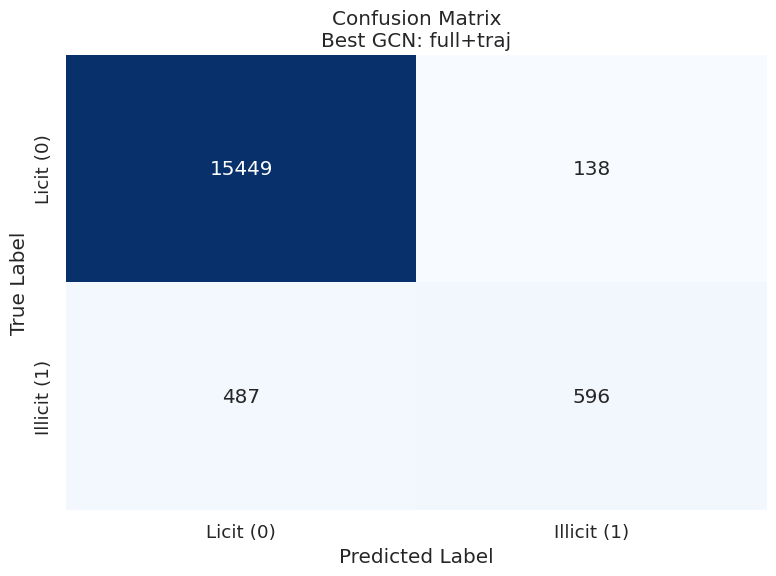

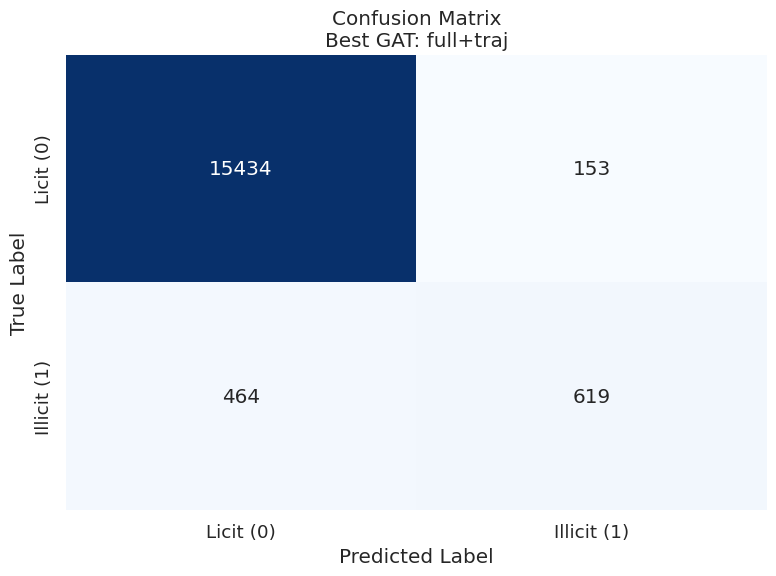

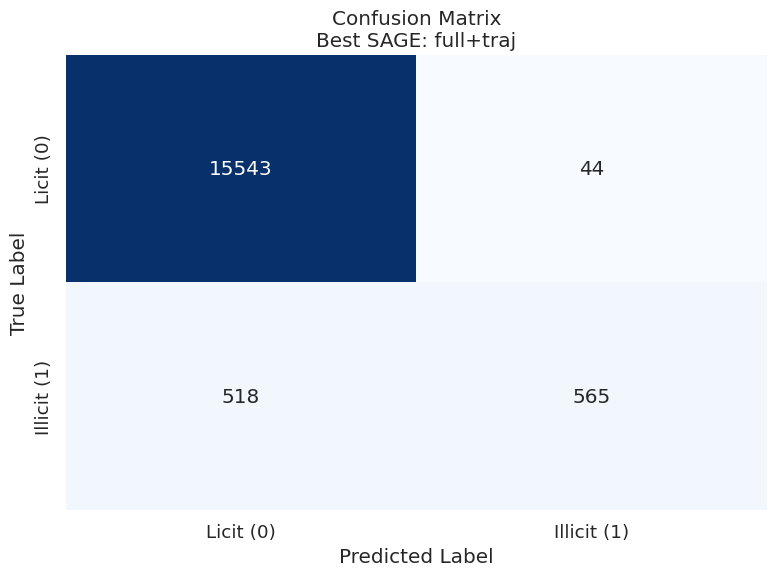

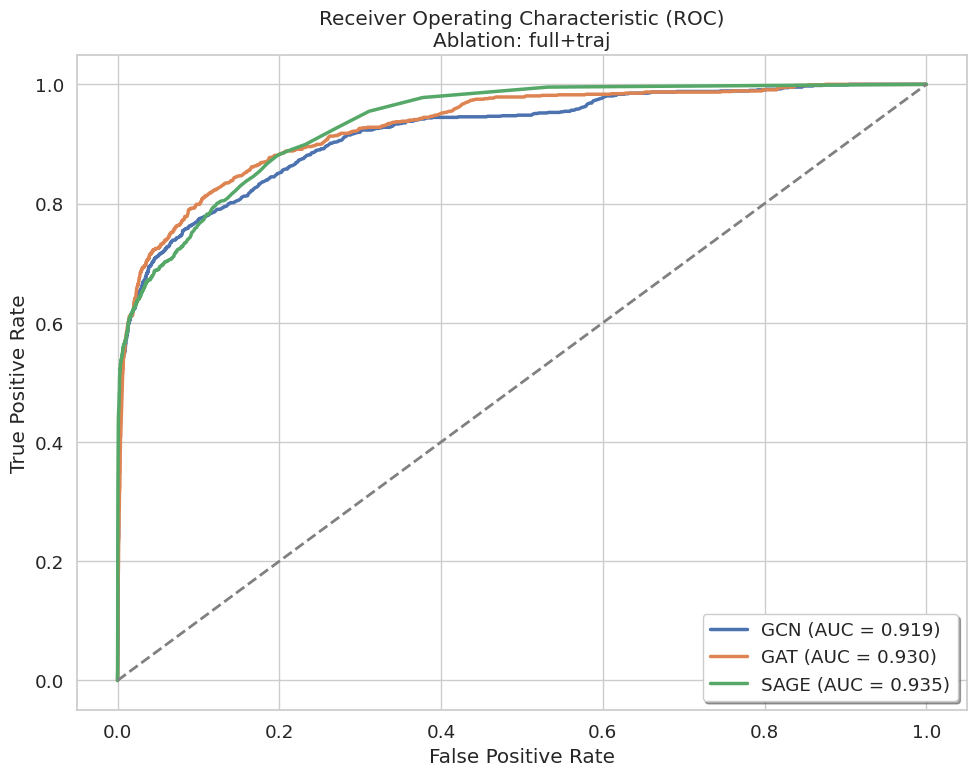

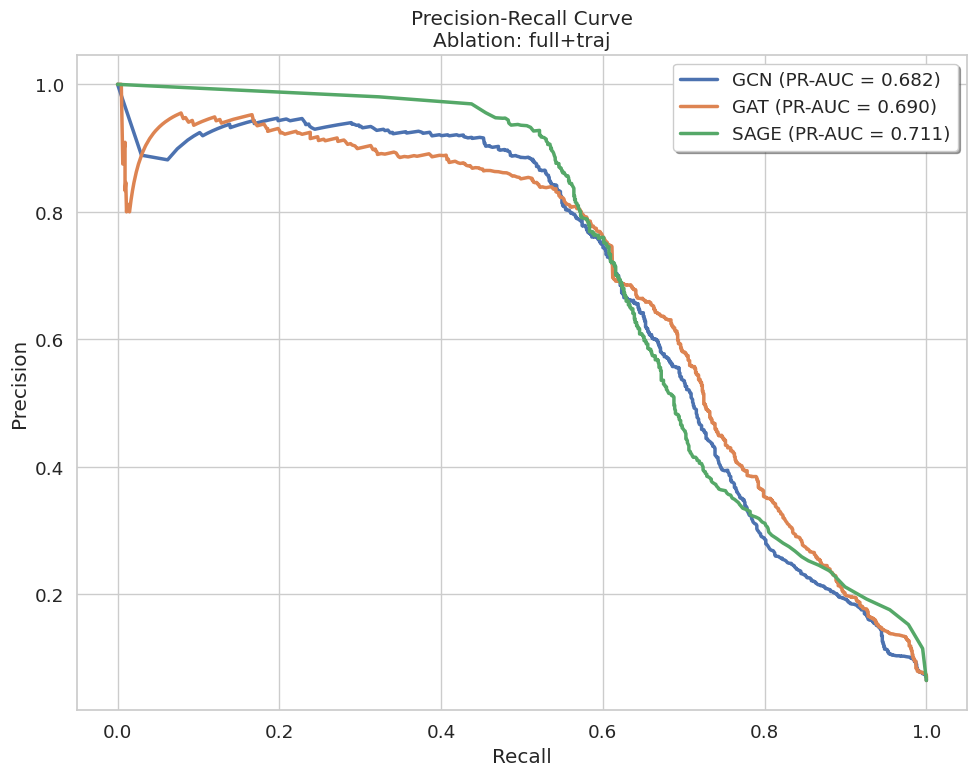

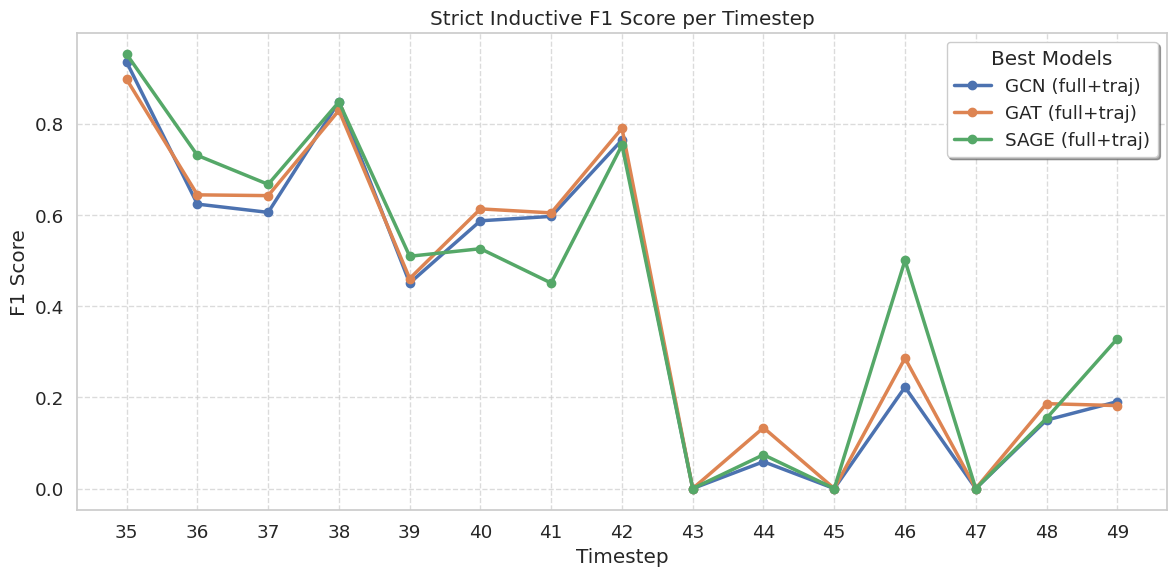

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, f1_score

# Set industry-standard styling for paper-ready plots
sns.set_theme(style="whitegrid", font_scale=1.2)

# Find the best ablation for each model architecture
best_per_model = {}
for m in MODEL_NAMES:
    best_ablation = max(ABLATIONS, key=lambda a: strict_results[(m, a)]['f1'])
    best_per_model[m] = best_ablation

# 1. Confusion Matrices (Separate Plots)
for m in MODEL_NAMES:
    best_ablation = best_per_model[m]
    res = strict_results[(m, best_ablation)]
    y_true = res['y_test']
    y_pred = (res['p_test'] >= res['thr']).astype(int)

    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Licit (0)', 'Illicit (1)'],
                yticklabels=['Licit (0)', 'Illicit (1)'])
    plt.title(f"Confusion Matrix\nBest {m.upper()}: {best_ablation}")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# 2. ROC Curve
plt.figure(figsize=(10, 8))
for model_name in MODEL_NAMES:
    key = (model_name, 'full+traj')
    if key in strict_results:
        res = strict_results[key]
        fpr, tpr, _ = roc_curve(res['y_test'], res['p_test'])
        plt.plot(fpr, tpr, lw=2.5, label=f"{model_name.upper()} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Receiver Operating Characteristic (ROC)\nAblation: full+traj')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
plt.figure(figsize=(10, 8))
for model_name in MODEL_NAMES:
    key = (model_name, 'full+traj')
    if key in strict_results:
        res = strict_results[key]
        prec, rec, _ = precision_recall_curve(res['y_test'], res['p_test'])
        plt.plot(rec, prec, lw=2.5, label=f"{model_name.upper()} (PR-AUC = {res['prauc']:.3f})")

plt.title('Precision-Recall Curve\nAblation: full+traj')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="upper right", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# 4. F1 Score per Timestep (Strict Inductive)
# Reconstruct test timestamps mapping since evaluation function iterates sequentially
test_times = []
for k in range(1, N_TIMESTEPS + 1):
    mask_k = m_test & (tx_t_arr == k)
    if mask_k.any():
        test_times.extend([k] * mask_k.sum())
test_times = np.array(test_times)

plt.figure(figsize=(12, 6))
for m in MODEL_NAMES:
    best_ablation = best_per_model[m]
    res = strict_results[(m, best_ablation)]

    y_test = res['y_test']
    p_test = res['p_test']
    thr = res['thr']

    timesteps = sorted(list(set(test_times)))
    f1_scores = []
    for t in timesteps:
        idx = (test_times == t)
        if idx.sum() > 0:
            y_t = y_test[idx]
            p_t = p_test[idx]
            f1 = f1_score(y_t, (p_t >= thr).astype(int), pos_label=1, zero_division=0)
            f1_scores.append(f1)
        else:
            f1_scores.append(np.nan)

    plt.plot(timesteps, f1_scores, marker='o', lw=2.5, label=f"{m.upper()} ({best_ablation})")

plt.title('Strict Inductive F1 Score per Timestep')
plt.xlabel('Timestep')
plt.ylabel('F1 Score')
plt.xticks(TEST_TIMESTEPS)
plt.legend(title="Best Models", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


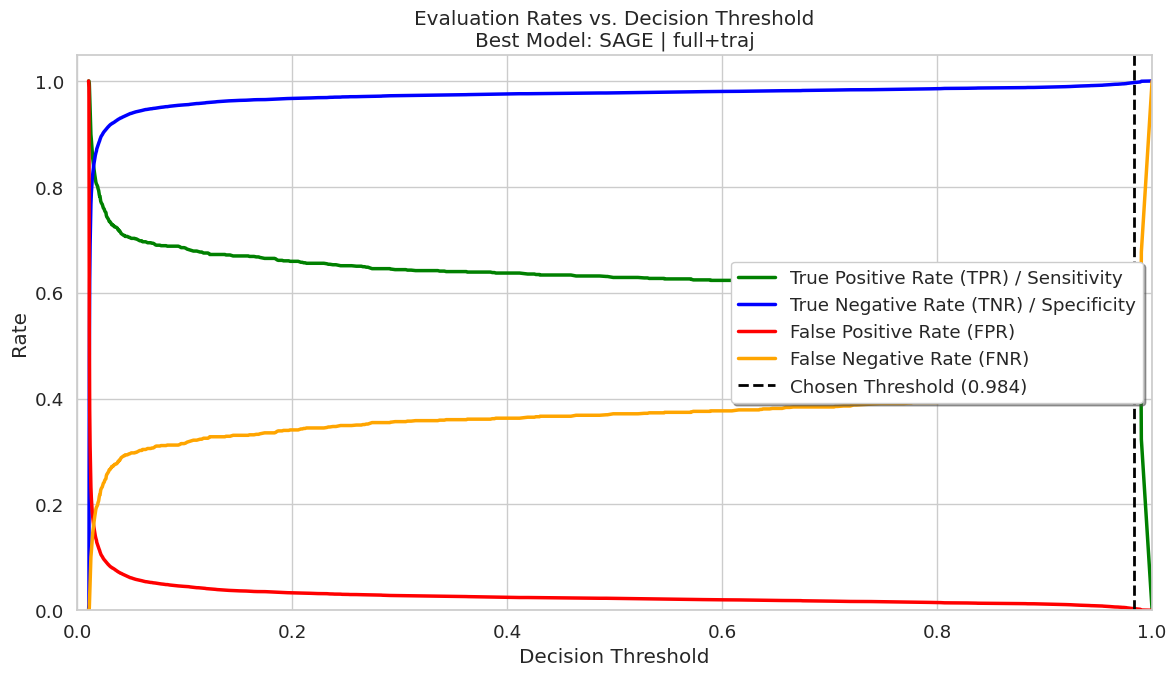

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Get the best model's predictions
best_model_key = max(strict_results, key=lambda k: strict_results[k]['f1'])
best_res = strict_results[best_model_key]
y_true = best_res['y_test']
p_pred = best_res['p_test']
best_thr = best_res['thr']

# Compute FPR, TPR, and Thresholds
fpr, tpr, thresholds = roc_curve(y_true, p_pred)
# sklearn roc_curve can return an arbitrary threshold > 1 for the first point, cap it at 1.0
thresholds = np.clip(thresholds, 0, 1)

# Derive FNR and TNR
fnr = 1 - tpr
tnr = 1 - fpr

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds, tpr, label='True Positive Rate (TPR) / Sensitivity', lw=2.5, color='green')
plt.plot(thresholds, tnr, label='True Negative Rate (TNR) / Specificity', lw=2.5, color='blue')
plt.plot(thresholds, fpr, label='False Positive Rate (FPR)', lw=2.5, color='red')
plt.plot(thresholds, fnr, label='False Negative Rate (FNR)', lw=2.5, color='orange')

# Mark the optimal threshold found during validation
plt.axvline(x=best_thr, color='black', linestyle='--', lw=2, label=f'Chosen Threshold ({best_thr:.3f})')

plt.title(f'Evaluation Rates vs. Decision Threshold\nBest Model: {best_model_key[0].upper()} | {best_model_key[1]}')
plt.xlabel('Decision Threshold')
plt.ylabel('Rate')
plt.legend(loc='center right', frameon=True, shadow=True)
plt.xlim(0, 1.0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Walk-forward evaluation

For each test timestep `t* ∈ [35, 49]`:
- Train a **fresh** model on `t ≤ t*-1` (single training-graph snapshot at `t*-1`)
- Val window `[t*-WALK_VAL_WIN..t*-1]`, per-timestep snapshots
- Test forward pass at exactly `t = t*` using `snapshot(t*)`

In [20]:
# Cell 11: walk-forward over (model, ablation, T) -- from-scratch each step

walk_results = {}
t_overall = time.time()

for mi, model_name in enumerate(MODEL_NAMES):
    for ai_, ablation in enumerate(["full+traj"]):  # Limited to full+traj
        tic_ma = time.time()
        per_T, pooled_p, pooled_y = {}, [], []

        for T in TEST_TIMESTEPS:
            v_lo = max(1, T - WALK_VAL_WIN)
            m_val_T   = labelled & (tx_t_arr >= v_lo) & (tx_t_arr <= T - 1)
            m_train_T = labelled & (tx_t_arr <= T - 1) & ~m_val_T
            m_test_T  = labelled & (tx_t_arr == T)
            if m_test_T.sum() == 0 or m_train_T.sum() == 0:
                continue

            seed = RANDOM_SEED + 1000 * mi + 100 * ai_ + T
            res = train_inductive(
                model_name=model_name, ablation=ablation,
                train_T_cutoff=T - 1,
                train_label_mask=m_train_T, val_label_mask=m_val_T, test_label_mask=m_test_T,
                n_epochs=N_EPOCHS_WALK, seed=seed, patience=PATIENCE,
            )
            per_T[T] = {"f1": res["f1"], "f1_05": res["f1_05"], "auc": res["auc"],
                        "prauc": res["prauc"], "n_test": res["n_test"]}
            pooled_p.append(res["p_test"]); pooled_y.append(res["y_test"])
            free_cuda()

        if pooled_p:
            P = np.concatenate(pooled_p); Y = np.concatenate(pooled_y)
            thr = _calibrate_threshold(Y, P)
            pooled = {
                "f1":    f1_score(Y, (P >= thr).astype(np.int64),  pos_label=1, zero_division=0),
                "f1_05": f1_score(Y, (P >= 0.5).astype(np.int64),  pos_label=1, zero_division=0),
                "auc":   roc_auc_score(Y, P),
                "prauc": average_precision_score(Y, P),
                "thr":   thr, "n_test": int(len(Y)),
            }
        else:
            pooled = {"f1": float("nan"), "f1_05": float("nan"), "auc": float("nan"),
                      "prauc": float("nan"), "thr": 0.5, "n_test": 0}

        walk_results[(model_name, ablation)] = {"per_T": per_T, "pooled": pooled}
        print(f"[walk] {model_name:>4} | {ablation:<16} | pooled "
              f"F1={pooled['f1']:.4f} F1@0.5={pooled['f1_05']:.4f} AUC={pooled['auc']:.4f} PR-AUC={pooled['prauc']:.4f} "
              f"({time.time()-tic_ma:.0f}s)")
        free_cuda()

print(f"\n[walk-forward total] {time.time()-t_overall:.0f}s")

[walk]  gcn | full+traj        | pooled F1=0.7226 F1@0.5=0.6432 AUC=0.9538 PR-AUC=0.7524 (2881s)
[walk]  gat | full+traj        | pooled F1=0.7141 F1@0.5=0.6825 AUC=0.9470 PR-AUC=0.7509 (3076s)
[walk] sage | full+traj        | pooled F1=0.6904 F1@0.5=0.6763 AUC=0.9277 PR-AUC=0.7286 (2937s)

[walk-forward total] 8895s


In [21]:
# Cell 12: walk-forward + combined summary

rows = []
for ablation in ["full+traj"]:
    for model_name in MODEL_NAMES:
        p = walk_results[(model_name, ablation)]["pooled"]
        rows.append([model_name, ablation, fmt_pct(p["f1"]), fmt_pct(p["f1_05"]), fmt_pct(p["auc"]), fmt_pct(p["prauc"]), p["n_test"]])
render_table(rows, ["model", "ablation", "F1[cal]", "F1@0.5", "AUC", "PR-AUC", "n_test"],
             "Walk-forward (pooled across T in [35..49])")
print()

print("=" * 100)
print("COMBINED RESULTS  (illicit class)")
print("=" * 100)
rows = []
for ablation in ABLATIONS:
    for model_name in MODEL_NAMES:
        s = strict_results[(model_name, ablation)]
        # Handle missing walk_forward results safely
        w = walk_results.get((model_name, ablation), {"pooled": {"f1": float('nan'), "f1_05": float('nan'), "auc": float('nan'), "prauc": float('nan')}})["pooled"]
        rows.append([
            model_name, ablation,
            fmt_pct(s["f1"]),  fmt_pct(s["f1_05"]),  fmt_pct(s["auc"]),  fmt_pct(s["prauc"]),
            fmt_pct(w["f1"]),  fmt_pct(w["f1_05"]),  fmt_pct(w["auc"]),  fmt_pct(w["prauc"]),
        ])
render_table(rows,
             ["model","ablation","F1[s]","F1@0.5[s]","AUC[s]","PR-AUC[s]","F1[w]","F1@0.5[w]","AUC[w]","PR-AUC[w]"],
             None)
print("\n[s]=strict-inductive  [w]=walk-forward")

Walk-forward (pooled across T in [35..49])
------------------------------------------
model  ablation   F1[cal]  F1@0.5  AUC     PR-AUC  n_test
-----  ---------  -------  ------  ------  ------  ------
gcn    full+traj  0.7226   0.6432  0.9538  0.7524  16670 
gat    full+traj  0.7141   0.6825  0.9470  0.7509  16670 
sage   full+traj  0.6904   0.6763  0.9277  0.7286  16670 

COMBINED RESULTS  (illicit class)
model  ablation        F1[s]   F1@0.5[s]  AUC[s]  PR-AUC[s]  F1[w]   F1@0.5[w]  AUC[w]  PR-AUC[w]
-----  --------------  ------  ---------  ------  ---------  ------  ---------  ------  ---------
gcn    bipartite       0.4482  0.4711     0.8764  0.2864       nan     nan        nan     nan    
gat    bipartite       0.5797  0.3814     0.8925  0.4269       nan     nan        nan     nan    
sage   bipartite       0.4671  0.4187     0.8785  0.3246       nan     nan        nan     nan    
gcn    +wallet_wallet  0.5233  0.4402     0.8923  0.4024       nan     nan        nan     nan    
g

In [22]:
# Cell 13: walk-forward per-timestep F1 detail

T_list = TEST_TIMESTEPS
header = ["model", "ablation"] + [str(t) for t in T_list] + ["pooled"]
rows = []
for ablation in ["full+traj"]:
    for model_name in MODEL_NAMES:
        wr = walk_results[(model_name, ablation)]
        per_T = wr["per_T"]
        row = [model_name, ablation]
        for T in T_list:
            row.append(f"{per_T[T]['f1']:.3f}" if T in per_T else " - ")
        row.append(f"{wr['pooled']['f1']:.3f}")
        rows.append(row)
render_table(rows, header, "Walk-forward per-timestep F1[cal]")

Walk-forward per-timestep F1[cal]
---------------------------------
model  ablation   35     36     37     38     39     40     41     42     43     44     45     46     47     48     49     pooled
-----  ---------  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  ------
gcn    full+traj  0.946  0.649  0.606  0.838  0.579  0.639  0.788  0.844  0.000  0.067  0.000  0.500  0.161  0.436  0.768  0.723 
gat    full+traj  0.890  0.688  0.676  0.880  0.677  0.677  0.847  0.852  0.000  0.057  0.000  0.000  0.177  0.613  0.351  0.714 
sage   full+traj  0.935  0.639  0.677  0.827  0.667  0.707  0.839  0.834  0.000  0.071  0.000  0.000  0.292  0.444  0.450  0.690 


Note: Pooled raw predictions (p_test, y_test) were not saved in 'walk_results' during Cell 11's execution.
Therefore, instead of aggregated ROC/PR curves and Confusion Matrices, we plot per-timestep metrics (AUC, PR-AUC, F1) to compare models.


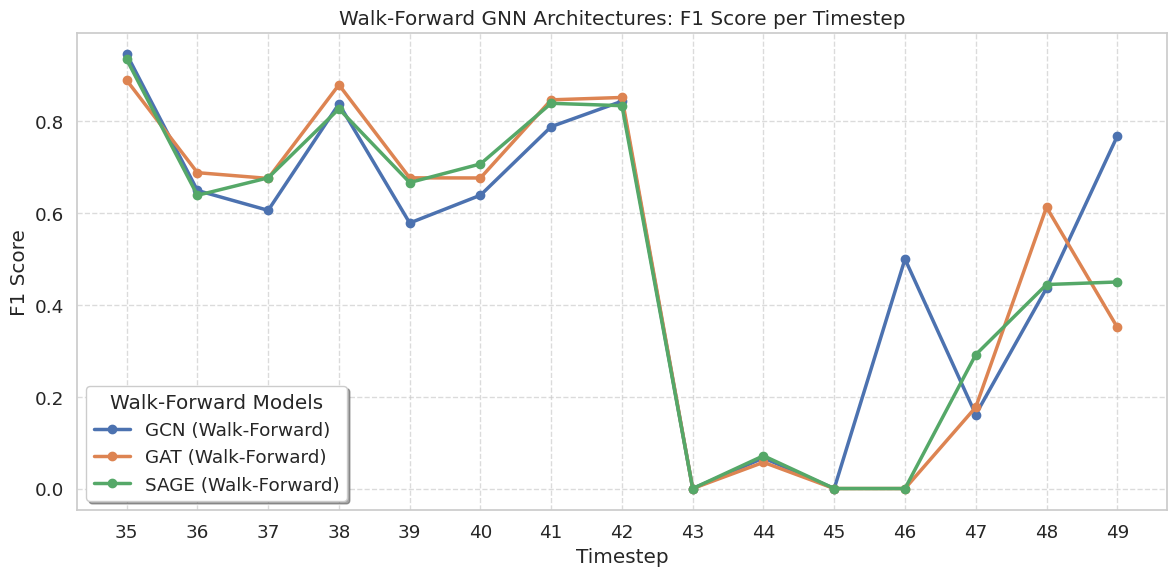

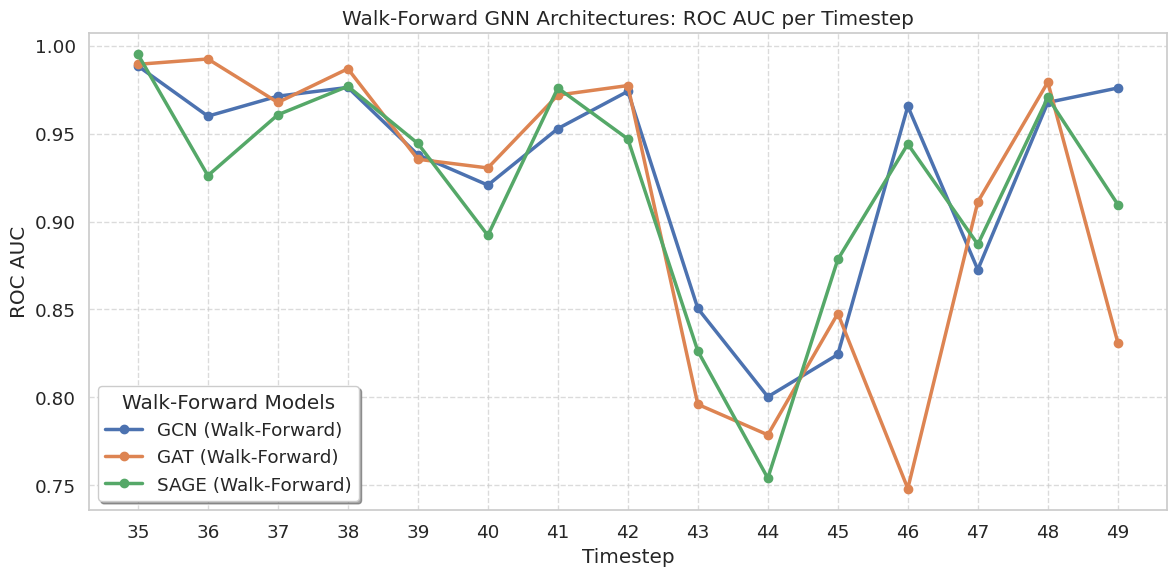

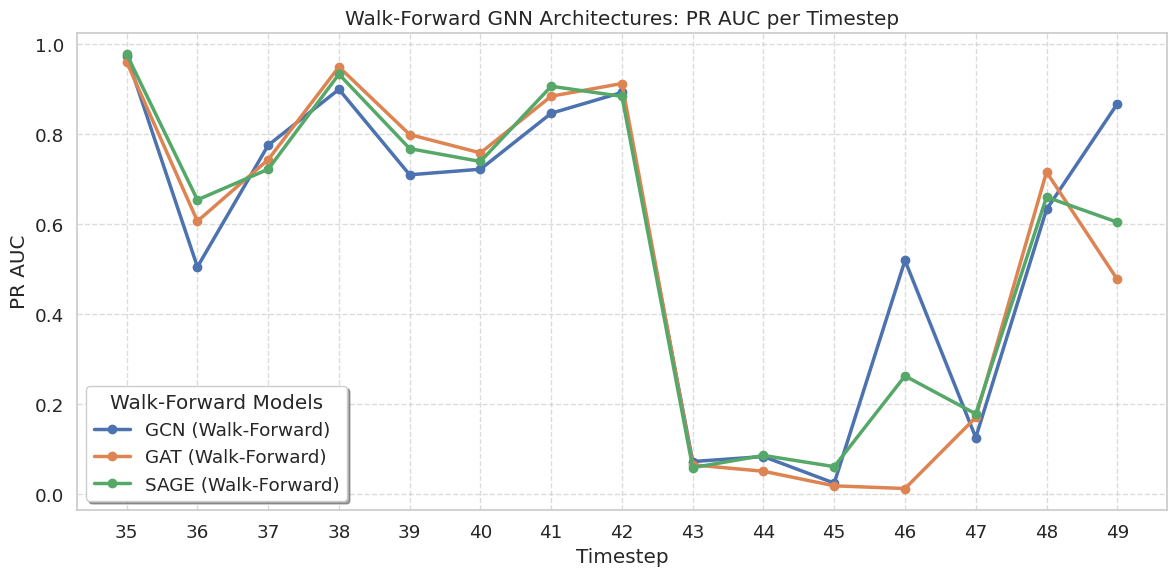

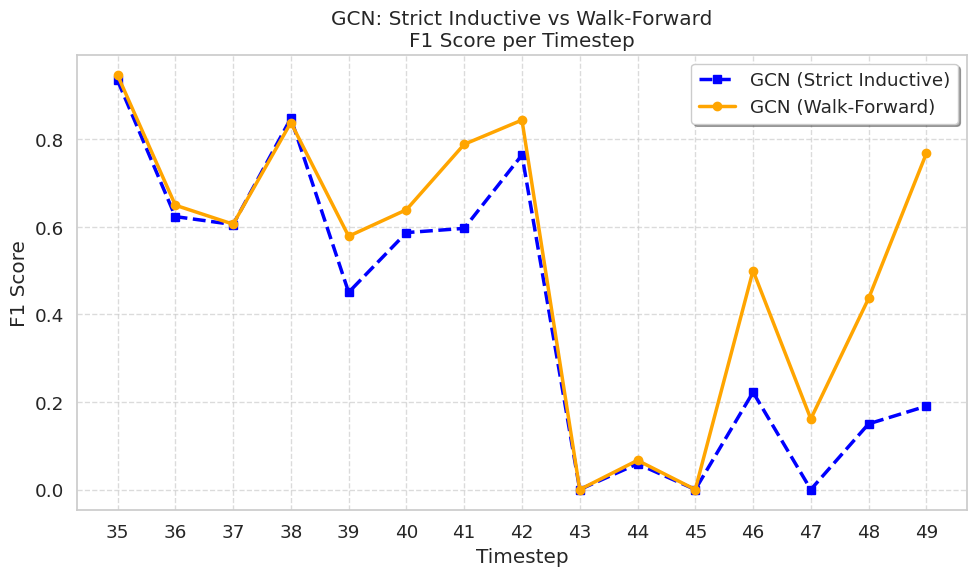

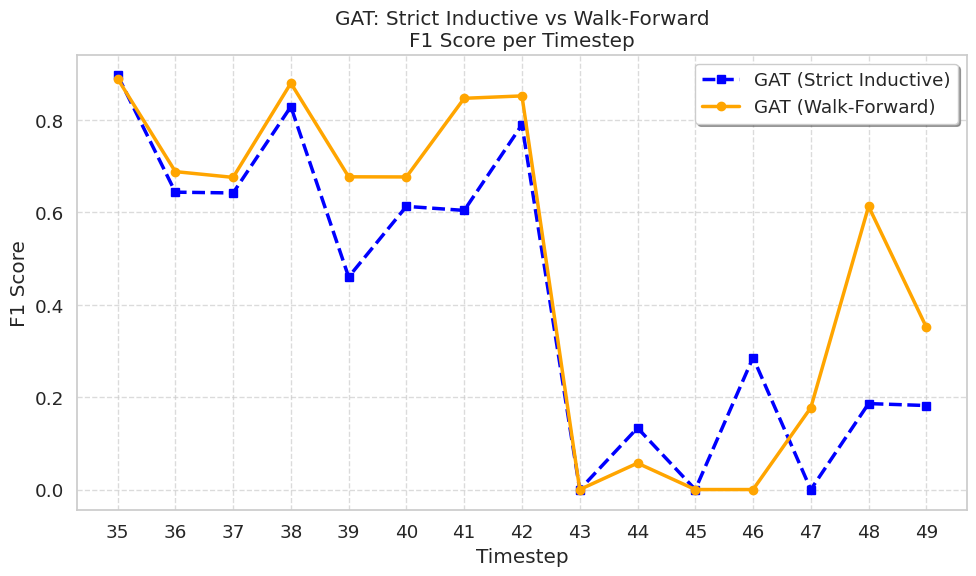

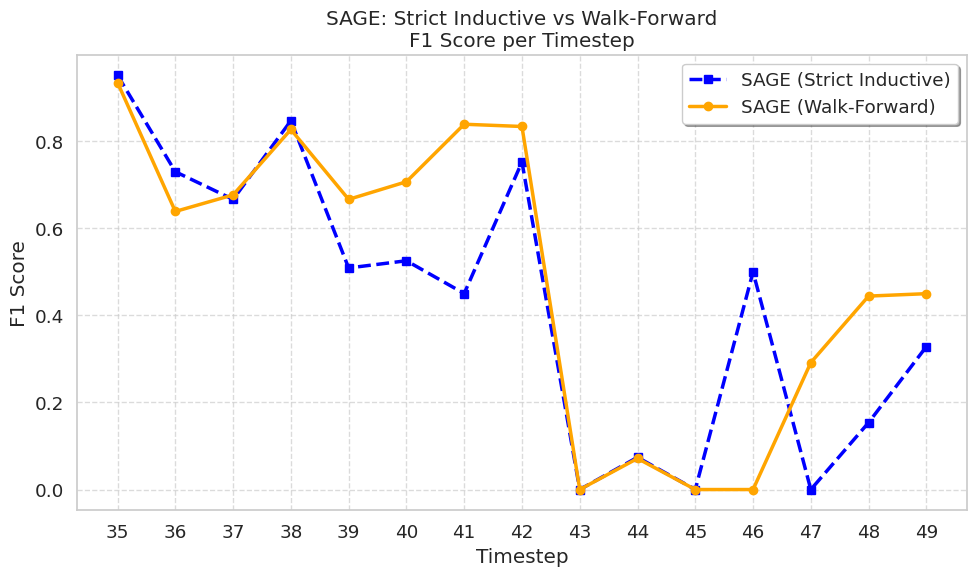

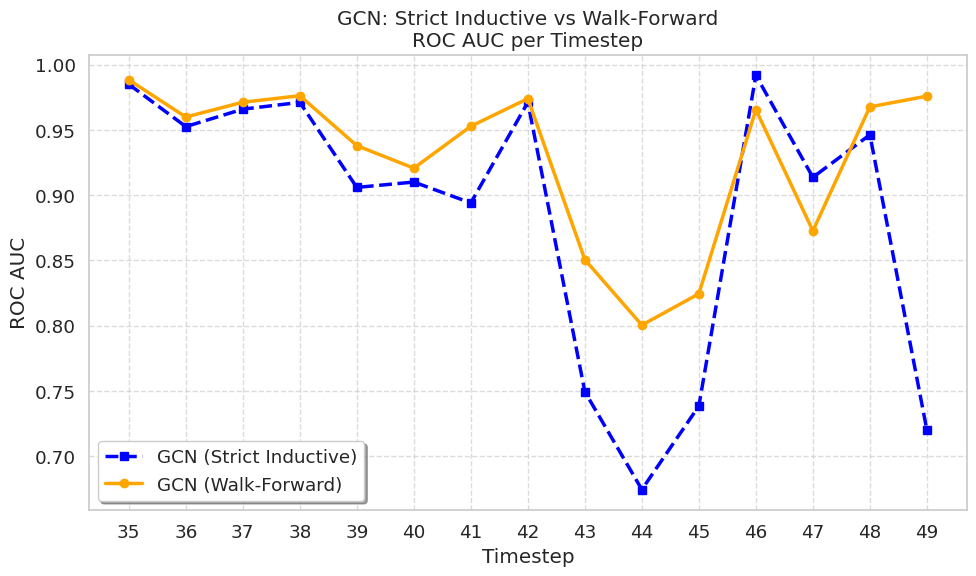

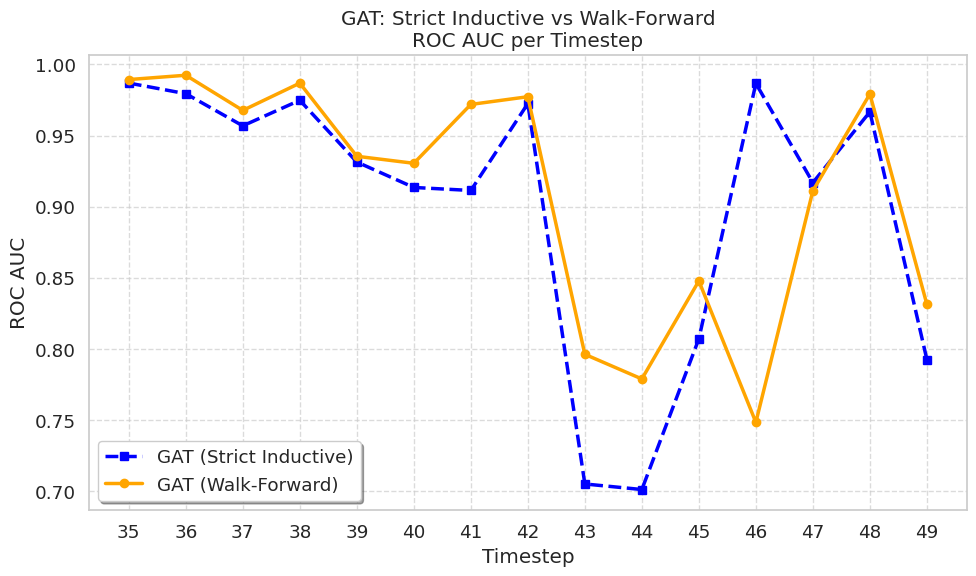

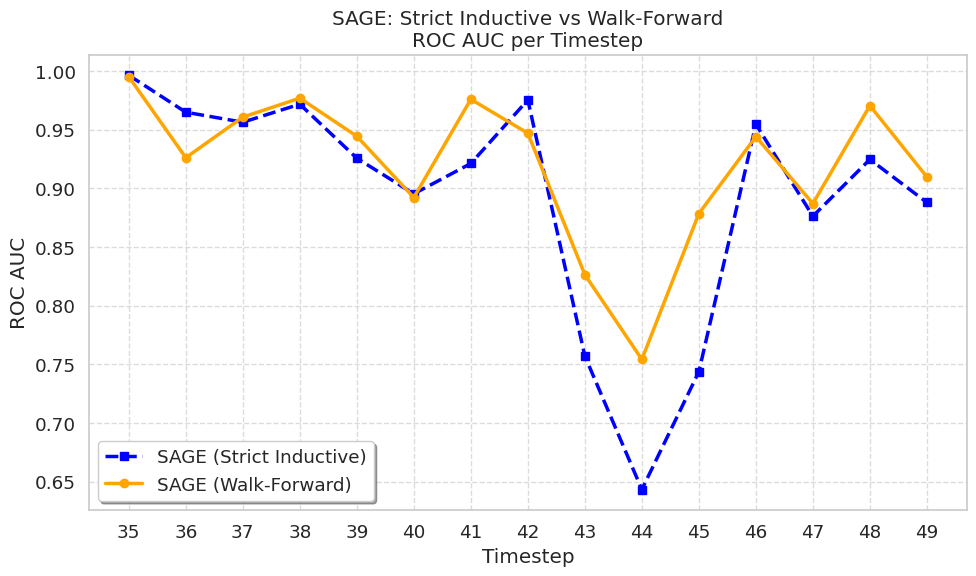

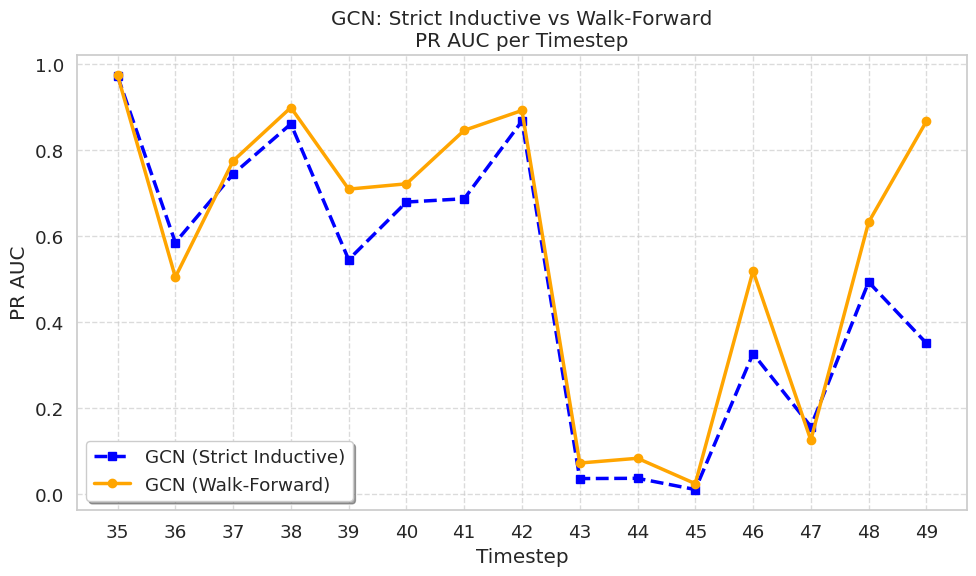

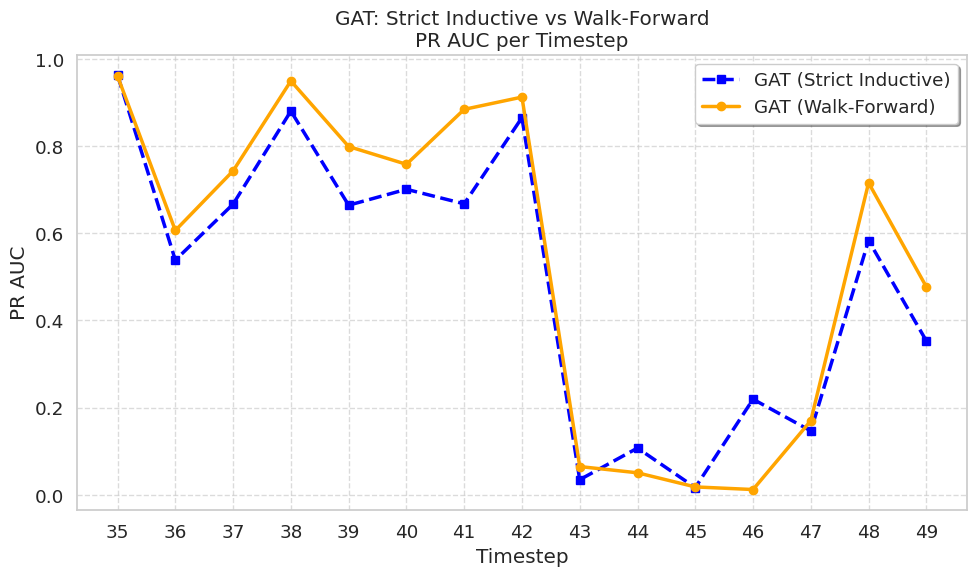

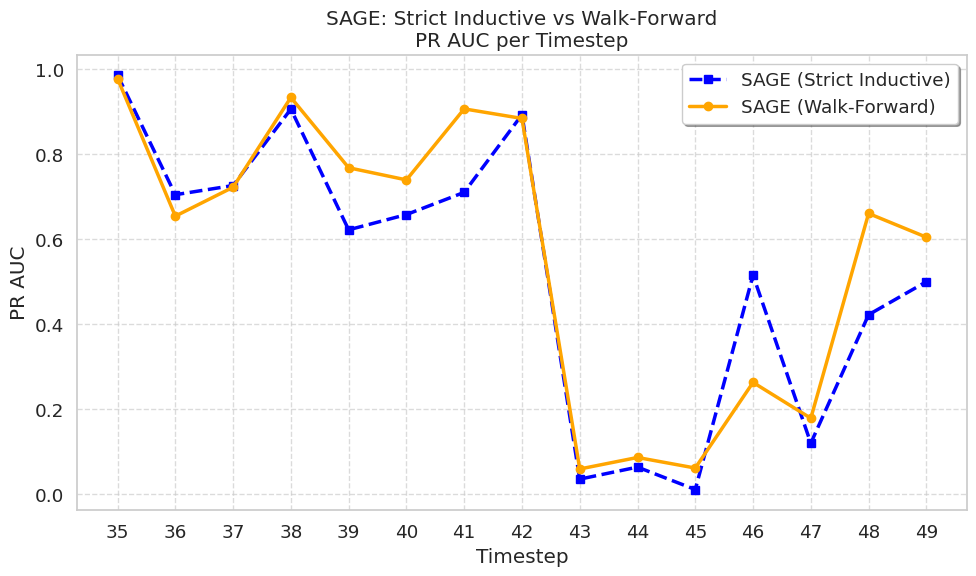

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

# Set industry-standard styling for paper-ready plots
sns.set_theme(style="whitegrid", font_scale=1.2)

print("Note: Pooled raw predictions (p_test, y_test) were not saved in 'walk_results' during Cell 11's execution.")
print("Therefore, instead of aggregated ROC/PR curves and Confusion Matrices, we plot per-timestep metrics (AUC, PR-AUC, F1) to compare models.")

# Ensure TEST_TIMESTEPS is available
TIMESTEPS = TEST_TIMESTEPS

# =========================================================
# 1. Walk-Forward Comparisons (F1, AUC, PR-AUC per timestep)
# =========================================================

metrics = [('f1', 'F1 Score'), ('auc', 'ROC AUC'), ('prauc', 'PR AUC')]

for metric_key, metric_name in metrics:
    plt.figure(figsize=(12, 6))
    for m in MODEL_NAMES:
        key = (m, 'full+traj')
        if key in walk_results:
            per_T = walk_results[key]['per_T']
            vals = [per_T[t][metric_key] if t in per_T else np.nan for t in TIMESTEPS]
            plt.plot(TIMESTEPS, vals, marker='o', lw=2.5, label=f"{m.upper()} (Walk-Forward)")

    plt.title(f'Walk-Forward GNN Architectures: {metric_name} per Timestep')
    plt.xlabel('Timestep')
    plt.ylabel(metric_name)
    plt.xticks(TIMESTEPS)
    plt.legend(title="Walk-Forward Models", frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# =========================================================
# 2. Strict Inductive vs Walk-Forward (Per Architecture)
# =========================================================

# Reconstruct strict inductive per-timestep metrics for full+traj to compare against WF
strict_per_T = {m: {'f1': [], 'auc': [], 'prauc': []} for m in MODEL_NAMES}

# Reconstruct test labels mapping for strict
test_times = []
for k in range(1, N_TIMESTEPS + 1):
    mask_k = m_test & (tx_t_arr == k)
    if mask_k.any():
        test_times.extend([k] * mask_k.sum())
test_times = np.array(test_times)

for m in MODEL_NAMES:
    key = (m, 'full+traj')
    if key in strict_results:
        res = strict_results[key]
        y_test_strict = res['y_test']
        p_test_strict = res['p_test']
        thr_strict = res['thr']

        for t in TIMESTEPS:
            idx = (test_times == t)
            if idx.sum() > 0:
                y_t = y_test_strict[idx]
                p_t = p_test_strict[idx]

                f1 = f1_score(y_t, (p_t >= thr_strict).astype(int), pos_label=1, zero_division=0)
                auc = roc_auc_score(y_t, p_t) if 0 < y_t.sum() < len(y_t) else np.nan
                prauc = average_precision_score(y_t, p_t) if y_t.sum() > 0 else np.nan

                strict_per_T[m]['f1'].append(f1)
                strict_per_T[m]['auc'].append(auc)
                strict_per_T[m]['prauc'].append(prauc)
            else:
                strict_per_T[m]['f1'].append(np.nan)
                strict_per_T[m]['auc'].append(np.nan)
                strict_per_T[m]['prauc'].append(np.nan)

# Plot Inductive vs Walk-Forward for each metric and architecture
for metric_key, metric_name in metrics:
    for m in MODEL_NAMES:
        plt.figure(figsize=(10, 6))

        # Inductive Line
        strict_vals = strict_per_T[m][metric_key]
        plt.plot(TIMESTEPS, strict_vals, marker='s', lw=2.5, linestyle='--', color='blue', label=f"{m.upper()} (Strict Inductive)")

        # Walk-Forward Line
        if (m, 'full+traj') in walk_results:
            per_T = walk_results[(m, 'full+traj')]['per_T']
            wf_vals = [per_T[t][metric_key] if t in per_T else np.nan for t in TIMESTEPS]
            plt.plot(TIMESTEPS, wf_vals, marker='o', lw=2.5, linestyle='-', color='orange', label=f"{m.upper()} (Walk-Forward)")

        plt.title(f'{m.upper()}: Strict Inductive vs Walk-Forward\n{metric_name} per Timestep')
        plt.xlabel('Timestep')
        plt.ylabel(metric_name)
        plt.xticks(TIMESTEPS)
        plt.legend(frameon=True, shadow=True)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
